# NDIBE IFEOMA - DATA SCIENCE INTERNSHIP 


## PROJECT 3 - JOB POST ANALYSIS

### INTRODUCTION

This project aims to apply data analysis techniques using Python.
By analyzing this data:

## It's objective is to provide valuable insights on:

The job market, assists job seekers, employers, and recruiters in making
informed decisions.

❑ Utilize Python libraries and tools to perform Exploratory Data Analysis
(EDA) on the collected job data.

❑ Identify trends, patterns, and insights related to the different technology
jobs.

❑ Visualize the analysis results using appropriate charts, graphs, and visual
representations.

In [212]:
!pip install wordcloud

In [213]:
import pandas as pd  # EDA AND Data preprocessing
import seaborn as sns # DATA VISUALIZATION
import numpy as np
import matplotlib.pyplot as plt #Data Visualization
import seaborn as sns #Data Visualization
import missingno as msno #Missing data - Data Visualization
import plotly.express as px # An interactive visualization libraryfrom datetime import datetime # For working with dates and times.
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import warnings
warnings.filterwarnings('ignore')

In [214]:
#reading in data
df= pd.read_csv(r"C:\Users\hp\Desktop\10ALYTICS\MACHINE LEARNING\INTERNSHIP\transformed_jobs_data.csv")

In [215]:
# Have a glimpse of the data.
df.head(3)

,job_id,job_employment_type,job_title,job_apply_link,job_description,job_city,job_country,job_posted_at_timestamp,employer_website,employer_company_type
0,XX6946dvNO3187IkAAAAAA==,FULLTIME,Data Engineer,https://ca.linkedin.com/jobs/view/data-enginee...,• *Please note that our offices will be closed...,Montréal,CA,12/19/2023 20:22,NaN,NaN
1,6Wu7QcWfrhOR-THoAAAAAA==,FULLTIME,Data Engineer,https://ca.linkedin.com/jobs/view/data-enginee...,We are seeking an experienced and passionate D...,NaN,CA,12/19/2023 15:55,NaN,NaN
2,Oiu186OT5E6bkZReAAAAAA==,FULLTIME,"2024 RBCIS, Summer Co-op Data Engineer / Full ...",https://ca.linkedin.com/jobs/view/2024-rbcis-s...,Job Summary\n\nJob Description\n\nWhat is the ...,Toronto,CA,12/19/2023 22:30,http://www.rbc.com,Finance


In [216]:
# Data Dimensionality on the number of rows and columns
df.shape

(166, 10)

In [217]:
# Investigate the dataset for anomalies and data types. 
# This will help in creating a variety of data visualizations
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   job_id                   166 non-null    object
 1   job_employment_type      166 non-null    object
 2   job_title                166 non-null    object
 3   job_apply_link           166 non-null    object
 4   job_description          166 non-null    object
 5   job_city                 128 non-null    object
 6   job_country              166 non-null    object
 7   job_posted_at_timestamp  166 non-null    object
 8   employer_website         113 non-null    object
 9   employer_company_type    76 non-null     object
dtypes: object(10)
memory usage: 13.1+ KB


In [218]:
#Examine the uniques feautures of the data
df.nunique()

job_id                     166
job_employment_type          4
job_title                   99
job_apply_link             166
job_description            153
job_city                    70
job_country                  3
job_posted_at_timestamp    139
employer_website            88
employer_company_type       13
dtype: int64

In [219]:
#Categorical Statistical Analysis and Transpose.
df.describe(include=["object", "bool"]).T

,count,unique,top,freq
job_id,166,166,XX6946dvNO3187IkAAAAAA==,1
job_employment_type,166,4,FULLTIME,153
job_title,166,99,Data Engineer,31
job_apply_link,166,166,https://ca.linkedin.com/jobs/view/data-enginee...,1
job_description,166,153,Job Description\n\nJob Summary:\n\nThis positi...,14
job_city,128,70,London,29
job_country,166,3,US,73
job_posted_at_timestamp,166,139,12/20/2023 0:00,7
employer_website,113,88,http://www.bdo.com,14
employer_company_type,76,13,Finance,18


## Observations¶
-  job_employment_type has 4 categories with Fulltime category having the highest freq of 153
-  job_title has 99 categories with Data Engineer category having the highest freq of 31
-  job_city: there are 70 cities in the dataset with London city having the highest freq of 29
-  job_country: the dataset has 3 countries with US having the highest job openings
-  employer_company_type: there are 13 company types with Fianace having the highest freq of 18
-  There are missing values in job_city, employer_website, and employer_company_type

## DATA CLEANING AND PREPROCESSING.

### INVESTIGATING THE MISSING DATA

In [220]:
#checking for missing features
null_vals=df.isnull().sum()

In [221]:
null_vals

job_id                      0
job_employment_type         0
job_title                   0
job_apply_link              0
job_description             0
job_city                   38
job_country                 0
job_posted_at_timestamp     0
employer_website           53
employer_company_type      90
dtype: int64

### IDENTIFY FILLING FACTOR OF MISSING NUMBERS.

In [222]:
missing_df = df.isnull().sum(axis=0).reset_index() # Calculate the number of NaN values in each column
missing_df.columns = ['variable', 'missing values'] # Rename the columns of the resulting DataFrame
missing_df['filling factor (%)']=(df.shape[0]-missing_df['missing values'])/df.shape[0]*100 # Calculate the percentage of missing values in each column
missing_df.sort_values('filling factor (%)').reset_index(drop = True) # Sort the resulting DataFrame by the percentage of missing values in descending order

,variable,missing values,filling factor (%)
0,employer_company_type,90,45.783133
1,employer_website,53,68.072289
2,job_city,38,77.108434
3,job_id,0,100.000000
4,job_employment_type,0,100.000000
5,job_title,0,100.000000
6,job_apply_link,0,100.000000
7,job_description,0,100.000000
8,job_country,0,100.000000
9,job_posted_at_timestamp,0,100.000000


Employer Company type has 90 missing values which is 46% data
Employer Website has 53 missing values which is 68% data
Job city has 38 missing values which is 77 data available.

They are all categorical data... I suggest we work with the data like that, when we get to machine learning we can drop irrelevant columns.

In [223]:
# Find the columns and rows with the missing values
df[df.isnull().any(axis=1)] 


,job_id,job_employment_type,job_title,job_apply_link,job_description,job_city,job_country,job_posted_at_timestamp,employer_website,employer_company_type
0,XX6946dvNO3187IkAAAAAA==,FULLTIME,Data Engineer,https://ca.linkedin.com/jobs/view/data-enginee...,• *Please note that our offices will be closed...,Montréal,CA,12/19/2023 20:22,NaN,NaN
1,6Wu7QcWfrhOR-THoAAAAAA==,FULLTIME,Data Engineer,https://ca.linkedin.com/jobs/view/data-enginee...,We are seeking an experienced and passionate D...,NaN,CA,12/19/2023 15:55,NaN,NaN
3,5y7azm6gLeu1ab_9AAAAAA==,FULLTIME,Lead Data Engineer,https://ca.linkedin.com/jobs/view/lead-data-en...,"Overview\n\nAt Nortal, we are driven by a gran...",NaN,CA,12/19/2023 17:06,http://www.nortal.com,Computer Services
6,aNFpD1P34-kK4vP3AAAAAA==,FULLTIME,Digital Data Analyst (Entry Level) (Fair Marke...,https://ca.linkedin.com/jobs/view/digital-data...,We are seeking a motivated and analytic indivi...,Vancouver,CA,12/20/2023 4:14,NaN,NaN
7,jnXVHj17uDvevrzNAAAAAA==,FULLTIME,Data Engineer,https://ca.bebee.com/job/20231219-5ac8f4a88517...,"Location:\nMontreal, Quebec\n\nOur client work...",Montréal,CA,12/19/2023 14:50,NaN,NaN
9,ZbkxbT56U2nkLJsNAAAAAA==,FULLTIME,Data Analyst,https://hitmarker.net/jobs/bethesda-data-analy...,Join Constellation!\n\nCome join Bethesda Game...,Montréal,CA,12/19/2023 12:22,NaN,NaN
11,DCiaYwjBQJ9bls9UAAAAAA==,FULLTIME,Senior Data Engineer (AI Platform),https://ca.linkedin.com/jobs/view/senior-data-...,About KOHO\n\nKOHO’s purpose is to empower Can...,NaN,CA,12/19/2023 21:10,http://www.koho.ca,NaN
12,UFOwMd1-oF78sr8CAAAAAA==,FULLTIME,Data Engineer,https://ca.bebee.com/job/20231219-57fde6e9ce3f...,"Data Engineer\nToronto, OntarioApplied Science...",Toronto,CA,12/19/2023 14:55,NaN,NaN
13,tLuaXjxoVLajUDKrAAAAAA==,FULLTIME,Associate Data Analyst,https://www.climatetechlist.com/job/terramera-...,Job posting details for Associate Data Analyst...,Vancouver,CA,12/20/2023 0:00,http://www.terramera.com,NaN
14,i5t7l6T2r-XkX5RBAAAAAA==,FULLTIME,Digital Data Analyst (Entry Level) (Fair Marke...,https://ca.linkedin.com/jobs/view/digital-data...,We are hiring a Data Entry Clerk to join our T...,Vancouver,CA,12/20/2023 4:14,NaN,NaN


In [224]:
df.columns

Index(['job_id', 'job_employment_type', 'job_title', 'job_apply_link',
       'job_description', 'job_city', 'job_country', 'job_posted_at_timestamp',
       'employer_website', 'employer_company_type'],
      dtype='object')

In [225]:
# Check for duplicates
print (df.duplicated().sum())

0


In [226]:
df.columns

Index(['job_id', 'job_employment_type', 'job_title', 'job_apply_link',
       'job_description', 'job_city', 'job_country', 'job_posted_at_timestamp',
       'employer_website', 'employer_company_type'],
      dtype='object')

# EXPLORATORY DATA ANALYSIS

## UNIVARIATE ANALYSIS 


# Job Employment Type Analysis below: 
FULLTIME - 92%
PARTTIME - 1%
INTERN - 1%
CONTRACTOR - 6%

FULLTIME      153
CONTRACTOR     10
INTERN          2
PARTTIME        1
Name: job_employment_type, dtype: int64


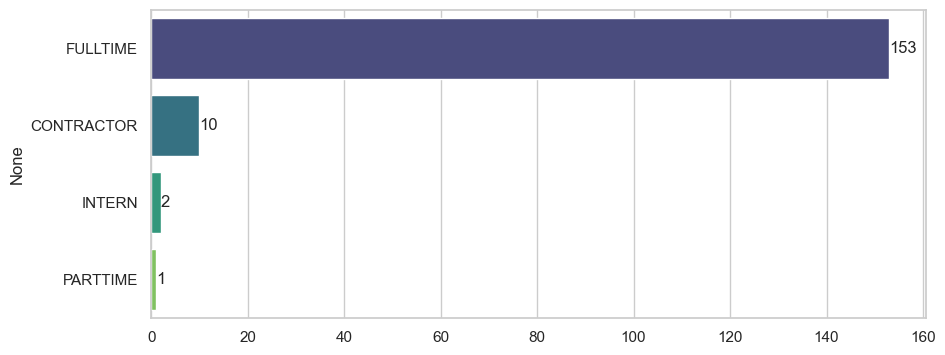

In [228]:
job_employment_type = df['job_employment_type'].value_counts()
print(job_employment_type)

# Plot a horizontal bar chart with values inside
plt.figure(figsize=(10, 4))
sns.barplot(x=job_employment_type.values, y=job_employment_type.index, palette="viridis")

# Display values inside the chart
for index, value in enumerate(job_employment_type.values):
    plt.text(value, index, str(value), va='center')

## JOB BY COUNTRY 

<AxesSubplot:ylabel='job_country'>

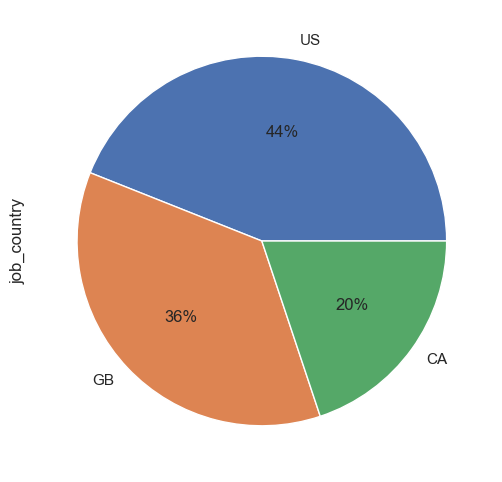

In [229]:
df.job_country .value_counts().plot(kind='pie', autopct='%1.0f%%', figsize=(6,6))

JOB BY COUNTRY ANALYSIS BREAKDOWN - Job openings

- I. Great Britain - 36%
- II. Uinted States - 44% 
- III. Canada - 20%

US    73
GB    60
CA    33
Name: job_country, dtype: int64


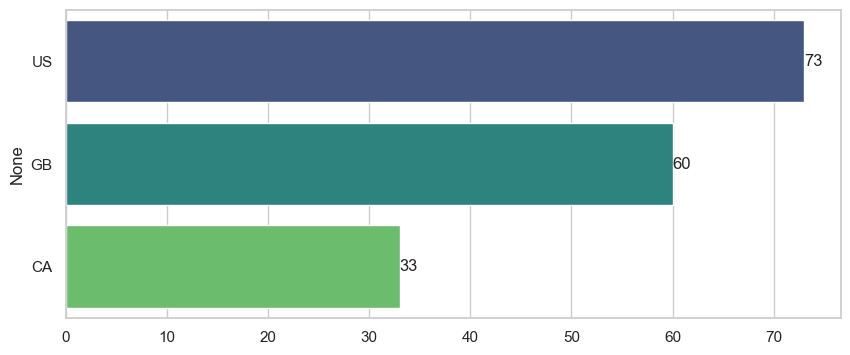

In [230]:
job_country_type = df['job_country'].value_counts()
print(job_country_type)

# Plot a horizontal bar chart with values inside
plt.figure(figsize=(10, 4))
sns.barplot(x=job_country_type.values, y=job_country_type.index, palette="viridis")

# Display values inside the chart
for index, value in enumerate(job_country_type.values):
    plt.text(value, index, str(value), va='center')

## JOB POST AT TIME STAMP

In [231]:
# Convert 'job_posted_at_timestamp' to datetime
df['job_posted_at_timestamp'] = pd.to_datetime(df['job_posted_at_timestamp'], format='%m/%d/%Y %H:%M')

# Display the DataFrame with the updated datetime format
df.head(3)

,job_id,job_employment_type,job_title,job_apply_link,job_description,job_city,job_country,job_posted_at_timestamp,employer_website,employer_company_type
0,XX6946dvNO3187IkAAAAAA==,FULLTIME,Data Engineer,https://ca.linkedin.com/jobs/view/data-enginee...,• *Please note that our offices will be closed...,Montréal,CA,2023-12-19 20:22:00,NaN,NaN
1,6Wu7QcWfrhOR-THoAAAAAA==,FULLTIME,Data Engineer,https://ca.linkedin.com/jobs/view/data-enginee...,We are seeking an experienced and passionate D...,NaN,CA,2023-12-19 15:55:00,NaN,NaN
2,Oiu186OT5E6bkZReAAAAAA==,FULLTIME,"2024 RBCIS, Summer Co-op Data Engineer / Full ...",https://ca.linkedin.com/jobs/view/2024-rbcis-s...,Job Summary\n\nJob Description\n\nWhat is the ...,Toronto,CA,2023-12-19 22:30:00,http://www.rbc.com,Finance


## TOP 20 JOB POSTED AT TIME STAMP

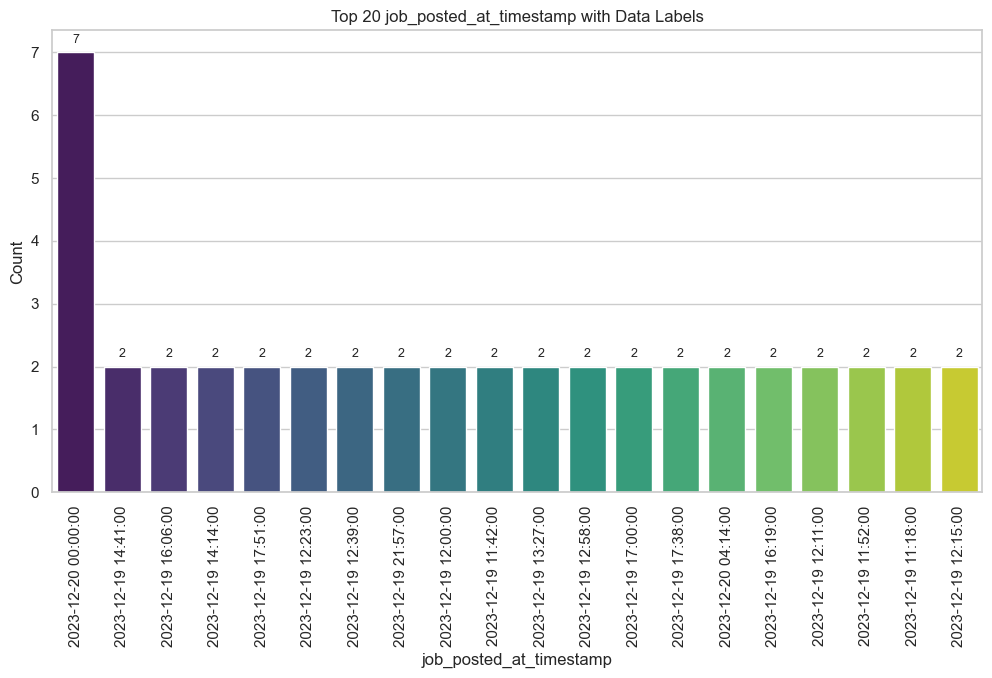

In [232]:
# Top Ten job_posted_at_timestamp
job_posted_at_timestamp = df["job_posted_at_timestamp"].value_counts().nlargest(20)

plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=job_posted_at_timestamp.index, y=job_posted_at_timestamp.values, palette='viridis')

# Add data labels on top of each bar
for index, value in enumerate(job_posted_at_timestamp):
    barplot.text(index, value + 0.1, str(value), ha='center', va='bottom', fontsize=9)

plt.title('Top 20 job_posted_at_timestamp with Data Labels')
plt.xlabel("job_posted_at_timestamp")
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

## LEAST 20 JOB POSTED AT TIMESTAMP

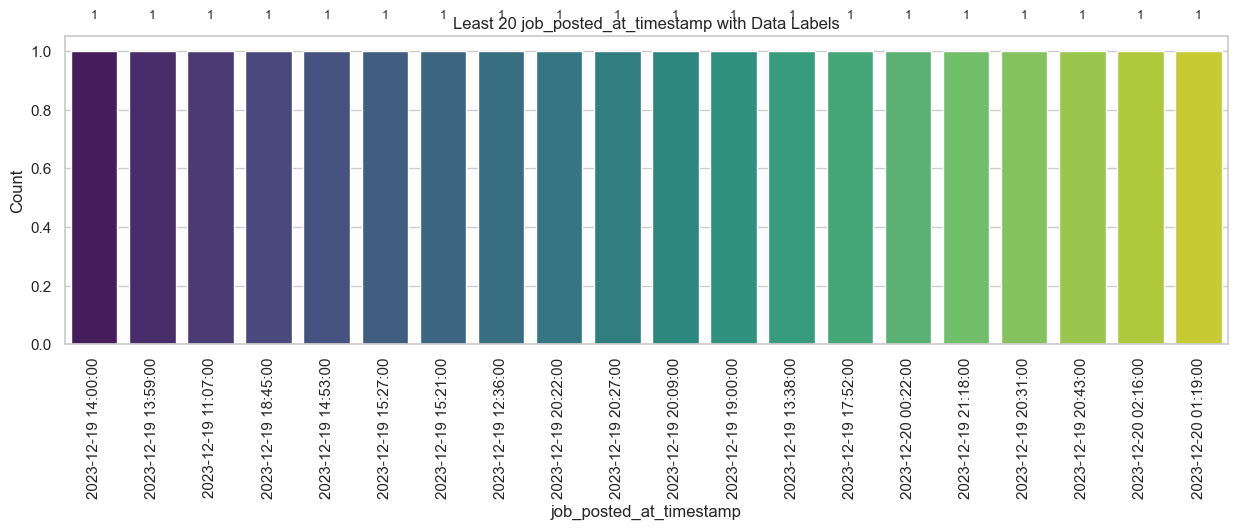

In [233]:
#Least Ten job_posted_at_timestamp
job_posted_at_timestamp = df["job_posted_at_timestamp"].value_counts().nsmallest(20)

plt.figure(figsize=(15, 4))
barplot = sns.barplot(x=job_posted_at_timestamp.index, y=job_posted_at_timestamp.values, palette='viridis')

# Add data labels on top of each bar
for index, value in enumerate(job_posted_at_timestamp):
    barplot.text(index, value + 0.1, str(value), ha='center', va='bottom', fontsize=9)

plt.title('Least 20 job_posted_at_timestamp with Data Labels')
plt.xlabel("job_posted_at_timestamp")
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

- Job Time Stamp was dated between 19/12/2023 and 20/12/2023.

The timestamp category "2023-12-20 00:00:00" stands out with 7 job postings, indicating a peak in job postings on this date.



## EMPLOYER COMPANY TYPE

Finance              18
Consulting           18
Manufacturing        10
Computer Services     9
Information           7
Education             3
Retail                3
Staffing              2
Construction          2
Utilities             1
Advertising           1
Restaurant            1
Logistics             1
Name: employer_company_type, dtype: int64


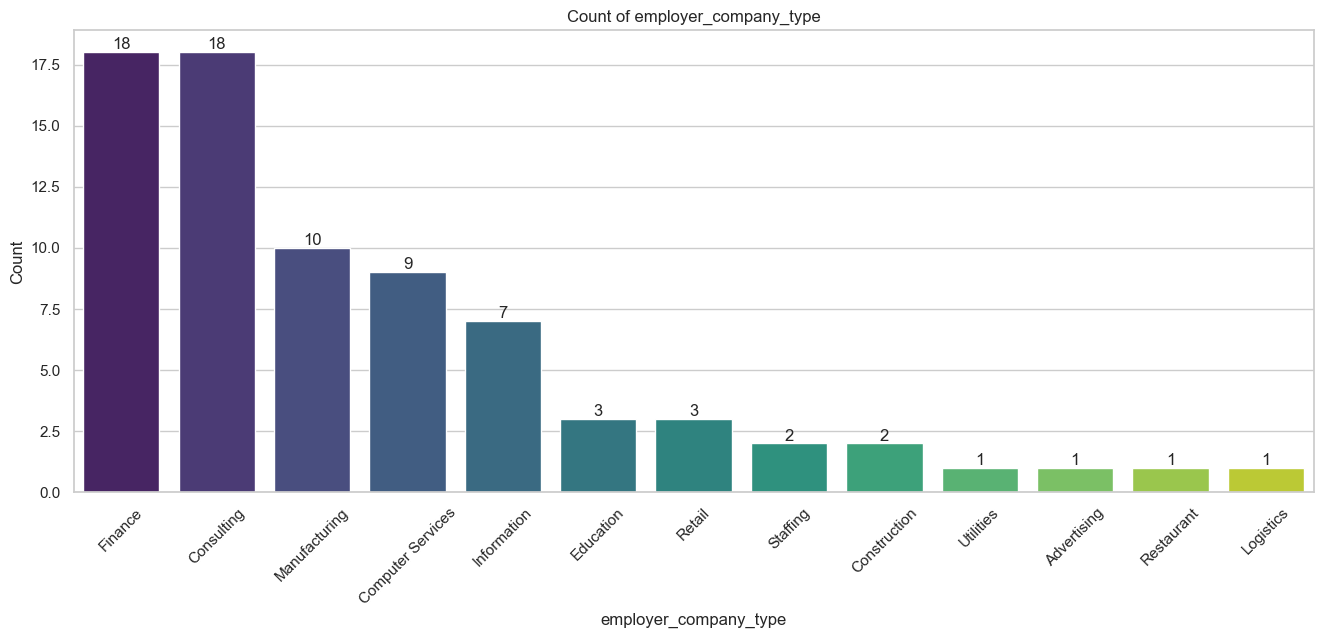

In [234]:
employer_company_type = df['employer_company_type'].value_counts()
print(employer_company_type)

# Assuming df is your DataFrame
plt.figure(figsize=(16, 6))

# Create a count plot with value counts displayed
sns.countplot(x="employer_company_type", data=df, palette='viridis', order=df["employer_company_type"].value_counts().index)

# Display the value counts on top of each bar
for index, value in enumerate(df["employer_company_type"].value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom')

# Set labels and title
plt.xlabel("employer_company_type")
plt.ylabel('Count')
plt.title('Count of employer_company_type')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()

## TOP 5 EMPLOYER COMPANY TYPE

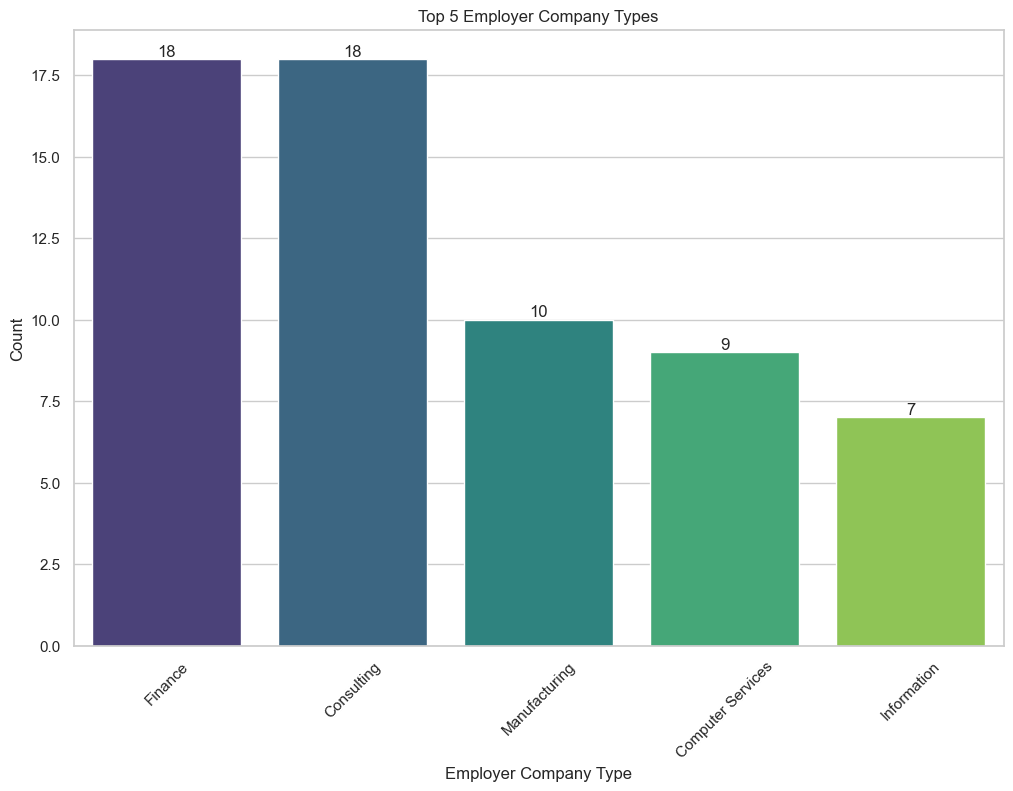

In [235]:
# Assuming df is your DataFrame
plt.figure(figsize=(12, 8))

# Get the top five employer_company_type counts
top_employer_types = df['employer_company_type'].value_counts().head(5)

# Create a bar plot
sns.barplot(x=top_employer_types.index, y=top_employer_types, palette='viridis')

# Display the count values on top of each bar
for index, value in enumerate(top_employer_types):
    plt.text(index, value, str(value), ha='center', va='bottom')

# Set labels and title
plt.xlabel('Employer Company Type')
plt.ylabel('Count')
plt.title('Top 5 Employer Company Types')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()


## LEAST EMPLOYER COMPANY TYPE

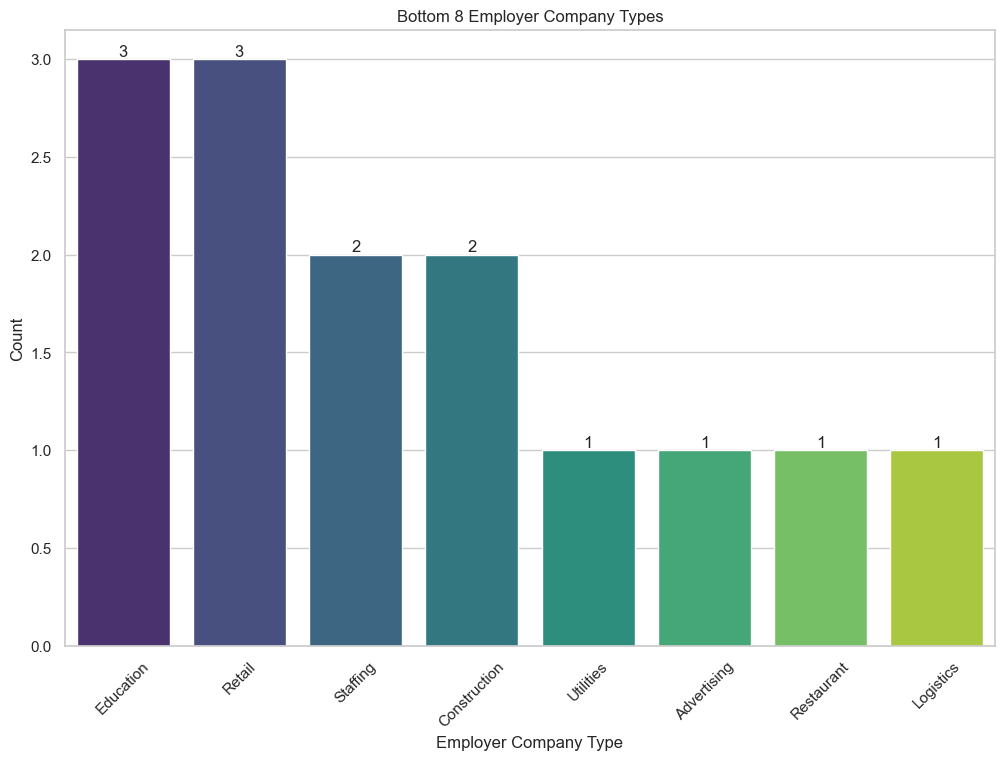

In [236]:

# Assuming df is your DataFrame
plt.figure(figsize=(12, 8))

# Get the bottom eight employer_company_type counts
bottom_employer_types = df['employer_company_type'].value_counts().tail(8)

# Create a bar plot
sns.barplot(x=bottom_employer_types.index, y=bottom_employer_types, palette='viridis')

# Display the count values on top of each bar
for index, value in enumerate(bottom_employer_types):
    plt.text(index, value, str(value), ha='center', va='bottom')

# Set labels and title
plt.xlabel('Employer Company Type')
plt.ylabel('Count')
plt.title('Bottom 8 Employer Company Types')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show the plot
plt.show()


## Observations
- Finance: There are 18 job postings associated with companies in the finance sector.

- Consulting: Another 18 job postings are related to consulting firms.

- Manufacturing: There are 10 job postings in the manufacturing industry.

- Computer Services: 9 job postings are linked to companies providing computer services.

- Information: 7 job postings are associated with companies in the information sector.

- Education: 3 job postings are from the education sector.

- Retail: There are 3 job postings in the retail industry.

- Staffing: 2 job postings are related to staffing agencies.

- Construction: 2 job postings are in the construction industry.

- Utilities: 1 job posting is linked to a utilities company.

- Advertising: 1 job posting is from the advertising sector.

- Restaurant: 1 job posting is related to the restaurant industry.

- Logistics: 1 job posting is associated with logistics.

# IMPLICATIONS FOR JOB SEEKERS:

## Diversify Job Search: 
    - Job seekers may want to consider diversifying their job search across various industries, especially those with a higher number of job postings, such as finance and consulting.
## Based on Industry Preferences: 
    - Individual preferences and career goals, job seekers are advised to focus on industries that align with their interests and skills. For Instance, Anyone who is interested in technology, ought to prioritize job postings in the "Computer Services" or "Information" categories.
## Competition Awareness: 
    - Knowing the number of job postings in each industry can give job seekers insights into the level of competition. Industries with fewer job postings may have more competitive hiring processes.

## JOB BY TITLE

In [237]:
df['job_title'].value_counts()

Data Engineer                                                                             31
Senior Cloud Data Engineer                                                                14
Senior Data Engineer                                                                      12
Data Analyst                                                                               6
Data Scientist                                                                             3
Lead Data Engineer                                                                         3
Senior Data Analyst                                                                        2
AWS Data Engineer                                                                          2
Splunk Data Engineer, Security                                                             2
Digital Data Analyst (Entry Level) (Fair Marketing Inc)                                    2
Sr. Data Analyst, Residential Energy Operations                       

In [238]:
df["job_title"].nunique

<bound method IndexOpsMixin.nunique of 0                                          Data Engineer
1                                          Data Engineer
2      2024 RBCIS, Summer Co-op Data Engineer / Full ...
3                                     Lead Data Engineer
4      2024 Investor Services - Business Data Analyst...
5                                          Data Engineer
6      Digital Data Analyst (Entry Level) (Fair Marke...
7                                          Data Engineer
8                                      Database Engineer
9                                           Data Analyst
10                                   Junior Data Analyst
11                    Senior Data Engineer (AI Platform)
12                                         Data Engineer
13                                Associate Data Analyst
14     Digital Data Analyst (Entry Level) (Fair Marke...
15                              Manager/ Data Analytics/
16                            Manager/Lead Data E

In [239]:
pd.set_option('display.max_rows', None) # DISPLAY ALL THE ROWS 
print(df['job_title'].head(99))

0                                         Data Engineer
1                                         Data Engineer
2     2024 RBCIS, Summer Co-op Data Engineer / Full ...
3                                    Lead Data Engineer
4     2024 Investor Services - Business Data Analyst...
5                                         Data Engineer
6     Digital Data Analyst (Entry Level) (Fair Marke...
7                                         Data Engineer
8                                     Database Engineer
9                                          Data Analyst
10                                  Junior Data Analyst
11                   Senior Data Engineer (AI Platform)
12                                        Data Engineer
13                               Associate Data Analyst
14    Digital Data Analyst (Entry Level) (Fair Marke...
15                             Manager/ Data Analytics/
16                           Manager/Lead Data Engineer
17    Manager, Data and Business Analytics (mana

## TOP 10 JOB TITLES

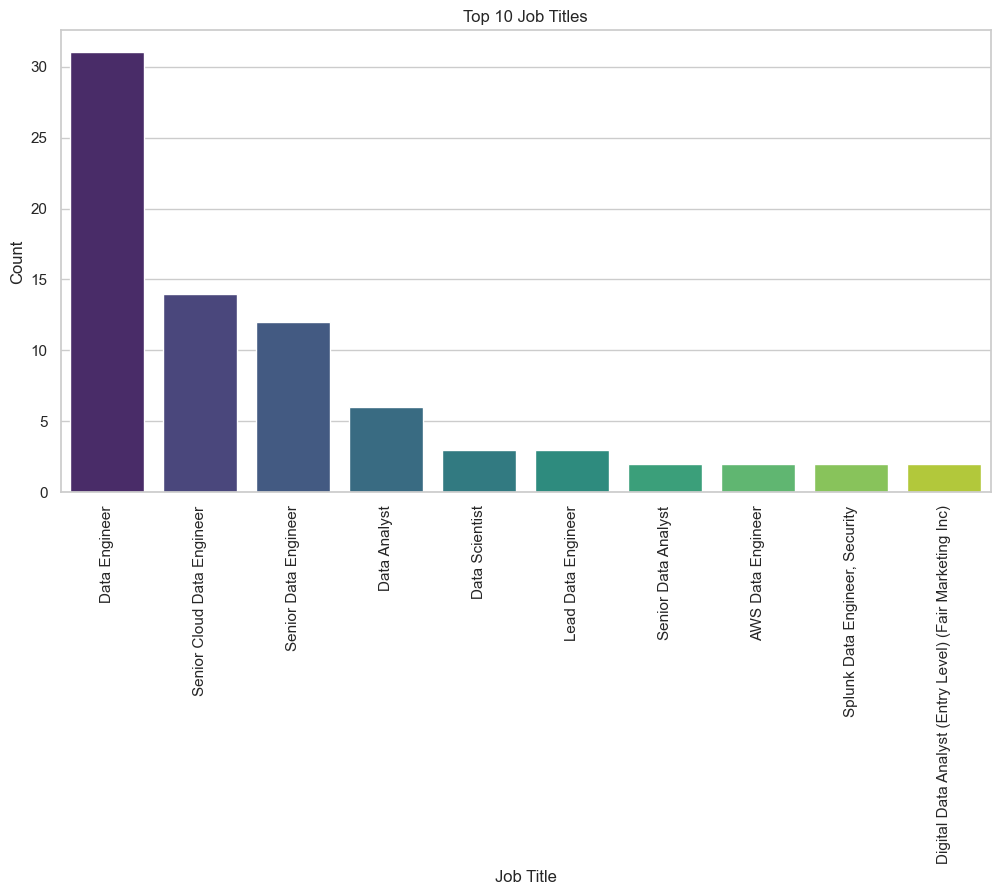

In [240]:
# Set the style for better visualization
sns.set(style="whitegrid")

# Top Ten Job Titles
top_job_titles = df['job_title'].value_counts().nlargest(10)


plt.figure(figsize=(12, 6))
sns.barplot(x=top_job_titles.index, y=top_job_titles.values, palette='viridis')
   
plt.title('Top 10 Job Titles')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

                       
    

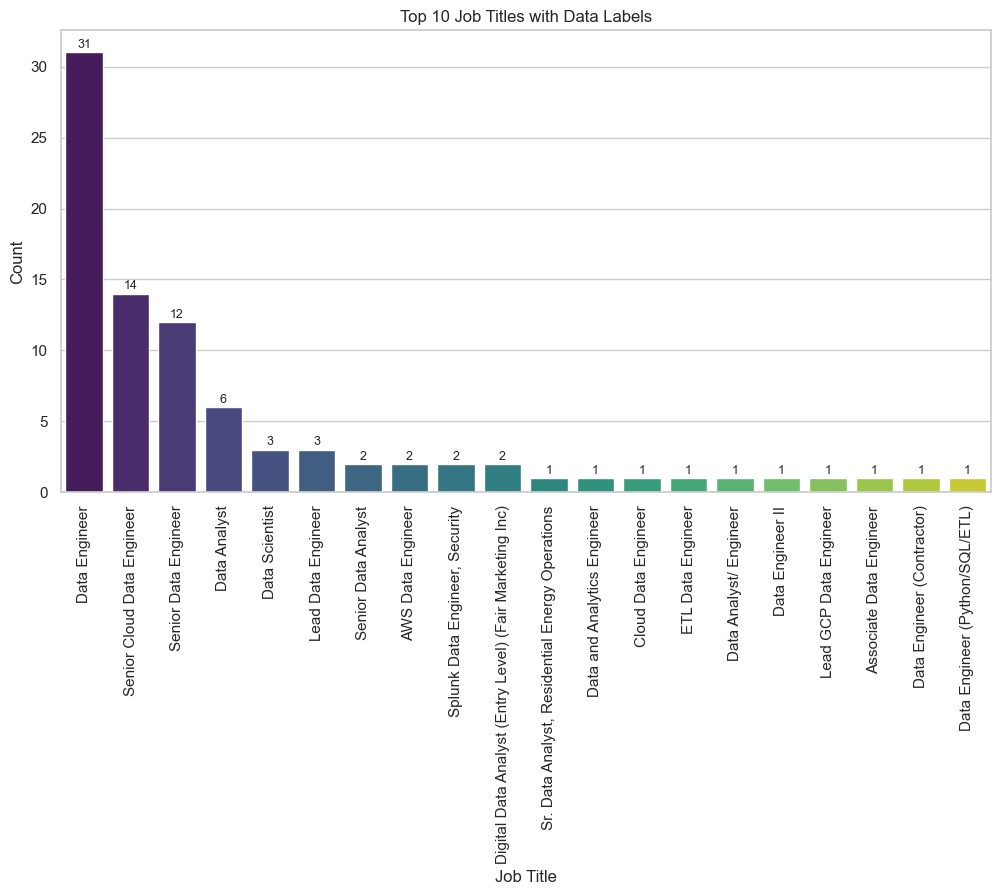

In [241]:
# Set the style for better visualization
sns.set(style="whitegrid")

# Top Ten Job Titles
top_job_titles = df['job_title'].value_counts().nlargest(20)

plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=top_job_titles.index, y=top_job_titles.values, palette='viridis')

# Add data labels on top of each bar
for index, value in enumerate(top_job_titles):
    barplot.text(index, value + 0.1, str(value), ha='center', va='bottom', fontsize=9)

plt.title('Top 10 Job Titles with Data Labels')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()


- Data Eng  	31
- SCDE      	14
- SDE     	12
- Data Analyst 6	
- Data Scientist	3
- Lead Data Eng  	1

- The  Data Engineer role is the most prevalent, with 31 postings.
This suggests a strong demand for professionals specializing in data engineering roles,
likely driven by the increasing reliance on data-driven decision-making
processes across industries.



- Google DevOps	1            
- Data Engineer          	1
- D.A /mgt Data A	1        
- Vibration Test	1   

- Roles such as “SCDE" (Senior Cloud Data Engineer) and "SDE" (Senior Data Engineer) also feature prominently, with 14 and 12 postings, respectively.   
- Google DevOps	1            
- There is also notable demand for data analysis and science roles. 

- Job titles such as "Data Analyst" and "Data Scientist" have 6 and 3 postings, respectively, suggesting a growing interest in leveraging data analytics and scientific methodologies to derive insights and inform decision-making processes.           
!

## LEAST 10 JOB TITLES

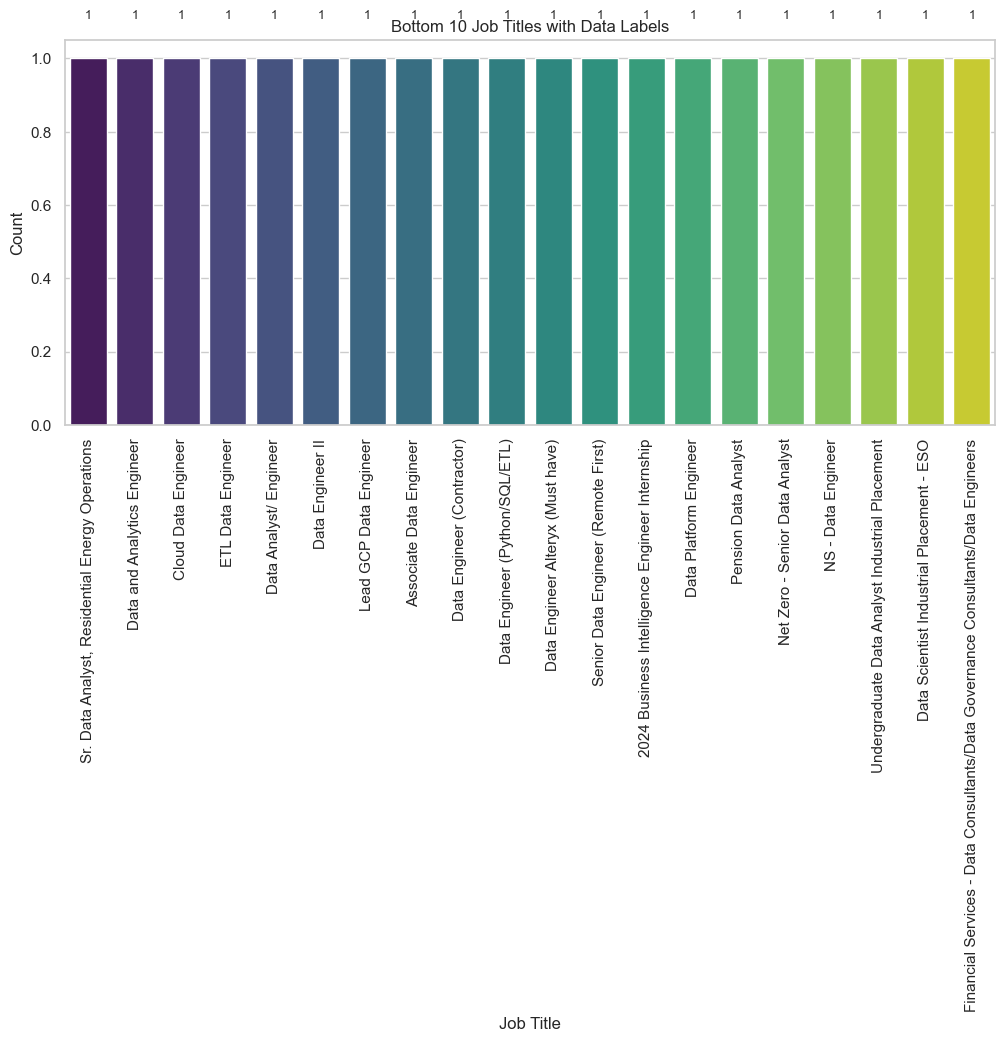

In [242]:

# Set the style for better visualization
sns.set(style="whitegrid")

# Bottom Ten Job Titles
bottom_job_titles = df['job_title'].value_counts().nsmallest(20)

plt.figure(figsize=(12, 5))
barplot = sns.barplot(x=bottom_job_titles.index, y=bottom_job_titles.values, palette='viridis')

# Add data labels on top of each bar
for index, value in enumerate(bottom_job_titles):
    barplot.text(index, value + 0.1, str(value), ha='center', va='bottom', fontsize=9)

plt.title('Bottom 10 Job Titles with Data Labels')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()


## JOB BY CITY

In [243]:
# Display the count of each job_city category
job_city = df["job_city"].value_counts()
print("Count of job_city Categories:")
print(job_city)
#job_city

Count of job_city Categories:
London                 29
Toronto                11
Montréal                4
Boston                  4
New York                4
Vancouver               3
Milton Keynes           2
Washington              2
Los Angeles             2
Jersey City             2
Dallas                  2
Austin                  2
Chicago                 2
Manchester              2
Bristol                 2
Fremont                 1
Palo Alto               1
Rockville               1
Columbus                1
Fort Worth              1
Richmond                1
Mountain View           1
Las Vegas               1
Grand Rapids            1
Baltimore               1
Columbia                1
Philadelphia            1
Miami                   1
Charlotte               1
Niles                   1
Claymont                1
West Palm Beach         1
Camden                  1
Seattle                 1
Rolling Meadows         1
Atlanta                 1
Plano                   1
Costa Me

## TOP 10 JOB CITIES

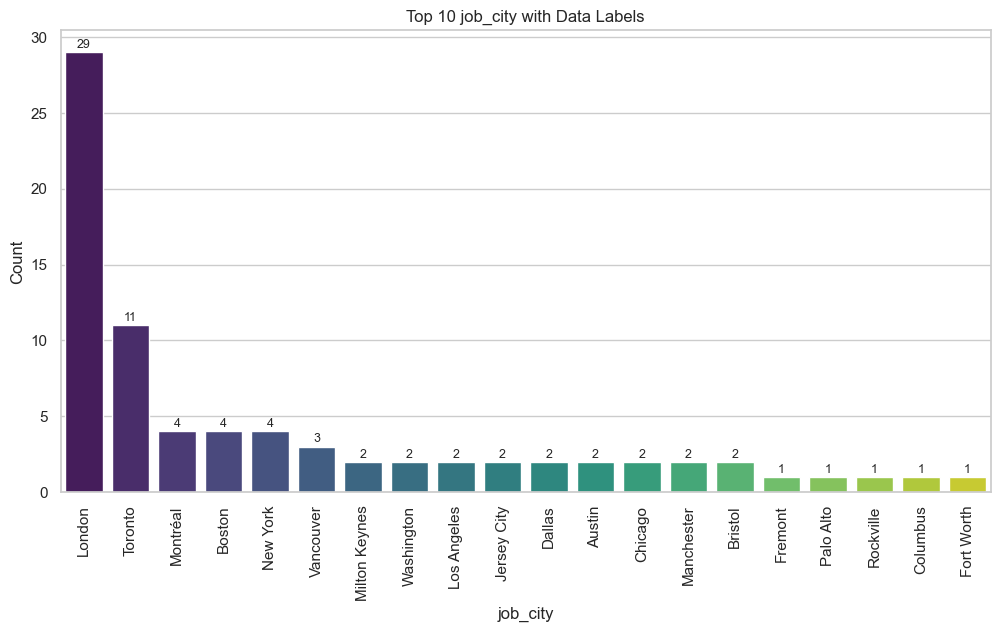

In [244]:
# Set the style for better visualization
sns.set(style="whitegrid")

# Top Ten Job Titles
top_job_city = df["job_city"].value_counts().nlargest(20)

plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=top_job_city.index, y=top_job_city.values, palette='viridis')

# Add data labels on top of each bar
for index, value in enumerate(top_job_city):
    barplot.text(index, value + 0.1, str(value), ha='center', va='bottom', fontsize=9)

plt.title('Top 10 job_city with Data Labels')
plt.xlabel("job_city")
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

- London and Toronto emerge as prominent job hubs, with 29 and 11 job postings,
respectively.

- This indicates a robust employment market in these metropolitan areas, 
offering diverse opportunities across various industries.


## LEAST 10 JOB CITIES

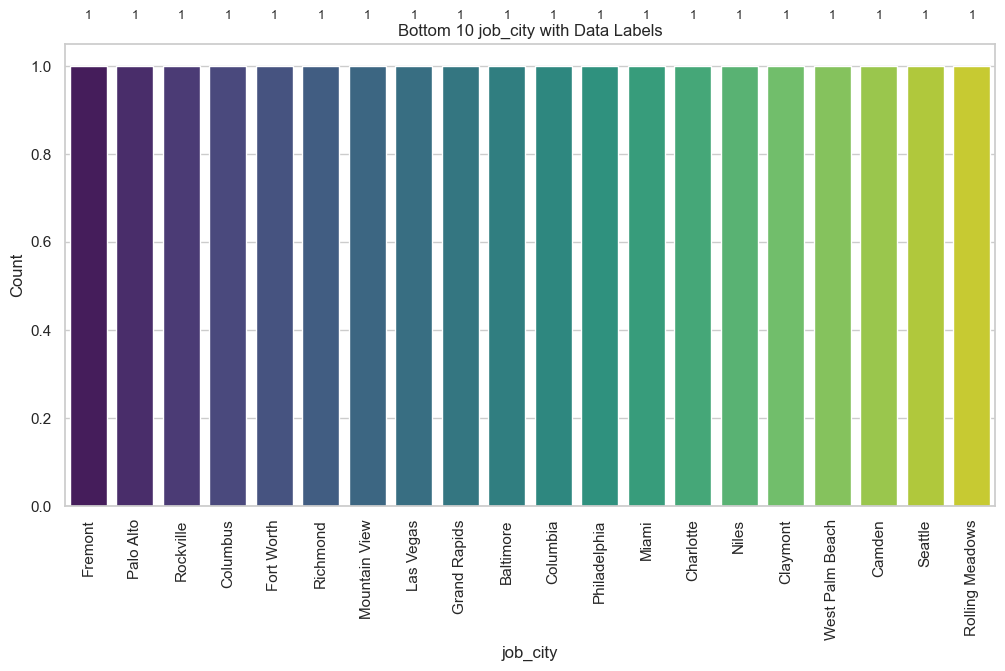

In [245]:
# Set the style for better visualization
sns.set(style="whitegrid")

# Top Ten Job Titles
bottom_job_city = df["job_city"].value_counts().nsmallest(20)

plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=bottom_job_city.index, y=bottom_job_city.values, palette='viridis')

# Add data labels on top of each bar
for index, value in enumerate(bottom_job_city):
    barplot.text(index, value + 0.1, str(value), ha='center', va='bottom', fontsize=9)

plt.title('Bottom 10 job_city with Data Labels')
plt.xlabel("job_city")
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

## EMPLOYER WEBSITE

In [246]:
# Display the count of each employer_website category
employer_website = df["employer_website"].value_counts()
print("Count of employer_website:")
#print(employer_website)
employer_website

Count of employer_website:


http://www.bdo.com                             14
http://www.agoda.com                            4
http://www.rbc.com                              3
http://www.tesla.com                            3
http://www.geturgently.com                      2
http://www.peraton.com                          2
http://www.grammarly.com                        2
http://www.altran.com                           2
http://www.natwestgroup.com                     2
http://www.ericsson.com                         1
http://waxcenter.com                            1
http://mgic.com                                 1
http://www.kalshi.com                           1
http://www.compunnel.com                        1
http://www.rhi.com                              1
http://www.vestis.com                           1
http://www.autoliv.com                          1
http://www.davidyurman.com                      1
http://www.amazon.com                           1
http://harnham.com                              1


In [253]:
!pip install urllib3

import warnings
warnings.filterwarnings('ignore')


In [255]:
from urllib.parse import urlparse

# Check for NaN values and fill them with an empty string
df['employer_website'].fillna('', inplace=True)

# Extract the site names from the URLs
site_names1 = [urlparse(str(url)).netloc for url in df['employer_website']]

# Convert the list to a pandas Series and get the unique counts
unique_site_counts = pd.Series(site_names1).value_counts()

# Display the unique counts of each URL
print(unique_site_counts)

                                        53
www.bdo.com                             14
www.agoda.com                            4
www.rbc.com                              3
www.tesla.com                            3
www.natwestgroup.com                     2
www.peraton.com                          2
www.grammarly.com                        2
www.geturgently.com                      2
www.altran.com                           2
www.buck.com                             1
harnham.com                              1
www.amazon.com                           1
www.ajg.com                              1
www.bloomberg.com                        1
www.autoliv.com                          1
www.detica.com                           1
www.vestis.com                           1
www.rhi.com                              1
www.compunnel.com                        1
www.kalshi.com                           1
risk.lexisnexis.com                      1
www.nationalgrideso.com                  1
mscience.co

In [256]:
!pip install tldextract

In [257]:
import pandas as pd
import tldextract

# Check for NaN values and fill them with an empty string
df['employer_website'].fillna('', inplace=True)

# Extract the domain and top-level domain (TLD) from the URLs
domain_and_tld = [tldextract.extract(url).domain + '.' + tldextract.extract(url).suffix for url in df['employer_website']]

# Convert the list to a pandas Series and get the unique counts
unique_domain_counts = pd.Series(domain_and_tld).value_counts()

# Display the unique counts of each domain
print(unique_domain_counts)


.                                   53
bdo.com                             14
agoda.com                            4
rbc.com                              3
tesla.com                            3
natwestgroup.com                     2
peraton.com                          2
grammarly.com                        2
geturgently.com                      2
altran.com                           2
buck.com                             1
harnham.com                          1
amazon.com                           1
ajg.com                              1
bloomberg.com                        1
autoliv.com                          1
detica.com                           1
vestis.com                           1
rhi.com                              1
compunnel.com                        1
kalshi.com                           1
lexisnexis.com                       1
nationalgrideso.com                  1
mscience.com                         1
oaknorth.co.uk                       1
waxcenter.com            

In [258]:
df.columns

Index(['job_id', 'job_employment_type', 'job_title', 'job_apply_link',
       'job_description', 'job_city', 'job_country', 'job_posted_at_timestamp',
       'employer_website', 'employer_company_type'],
      dtype='object')

## TOP 20 EMPLOYERS WEBSITE

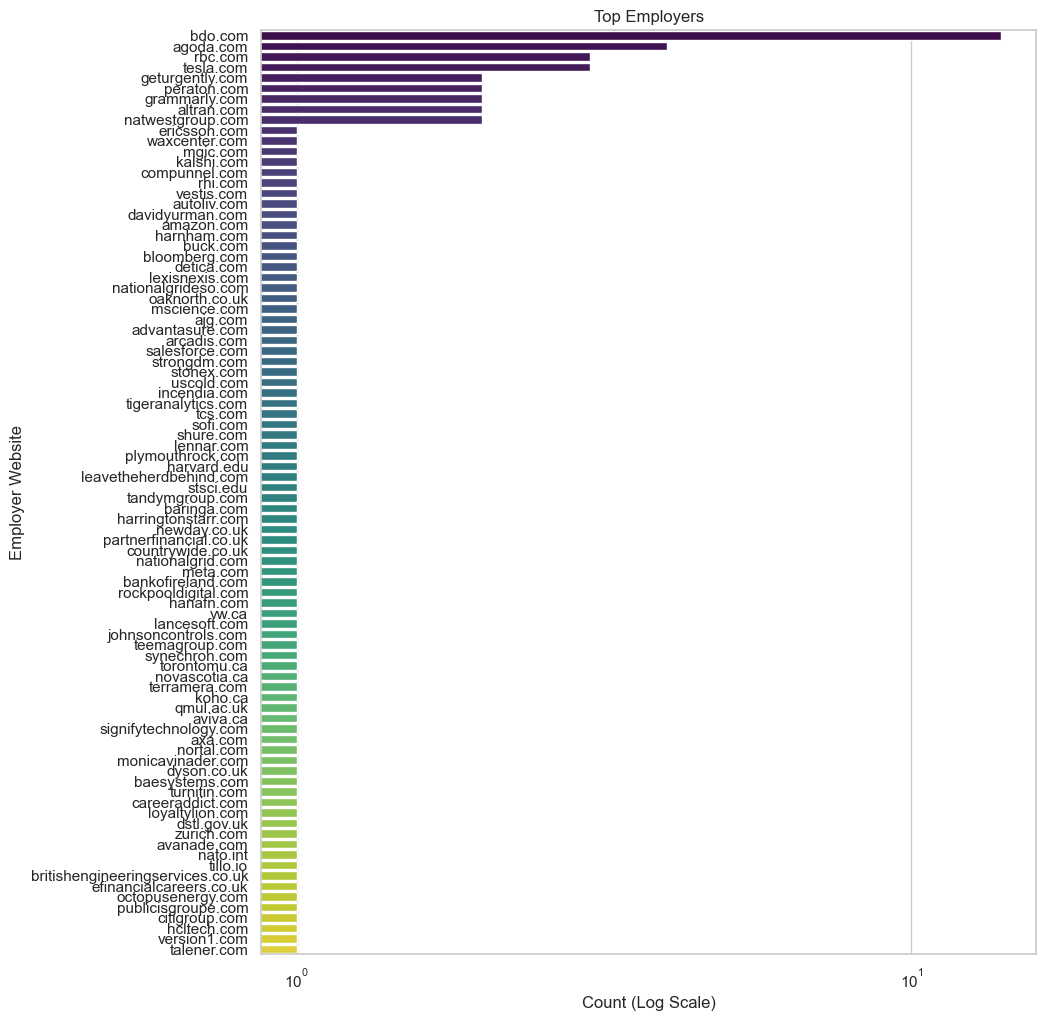

In [259]:
# Top 20 EMPLOYER WEBSITES

# Plot a horizontal bar chart with logarithmic scale
plt.figure(figsize=(10, 12))
sns.barplot(x=cleaned_counts.values, y=cleaned_counts.index, palette="viridis")
plt.xscale('log')

plt.title('Top Employers')
plt.xlabel('Count (Log Scale)')
plt.ylabel('Employer Website')

plt.show()

## TREE MAP FOR EMPLOYER WEBSITE

In [260]:
!pip install squarify

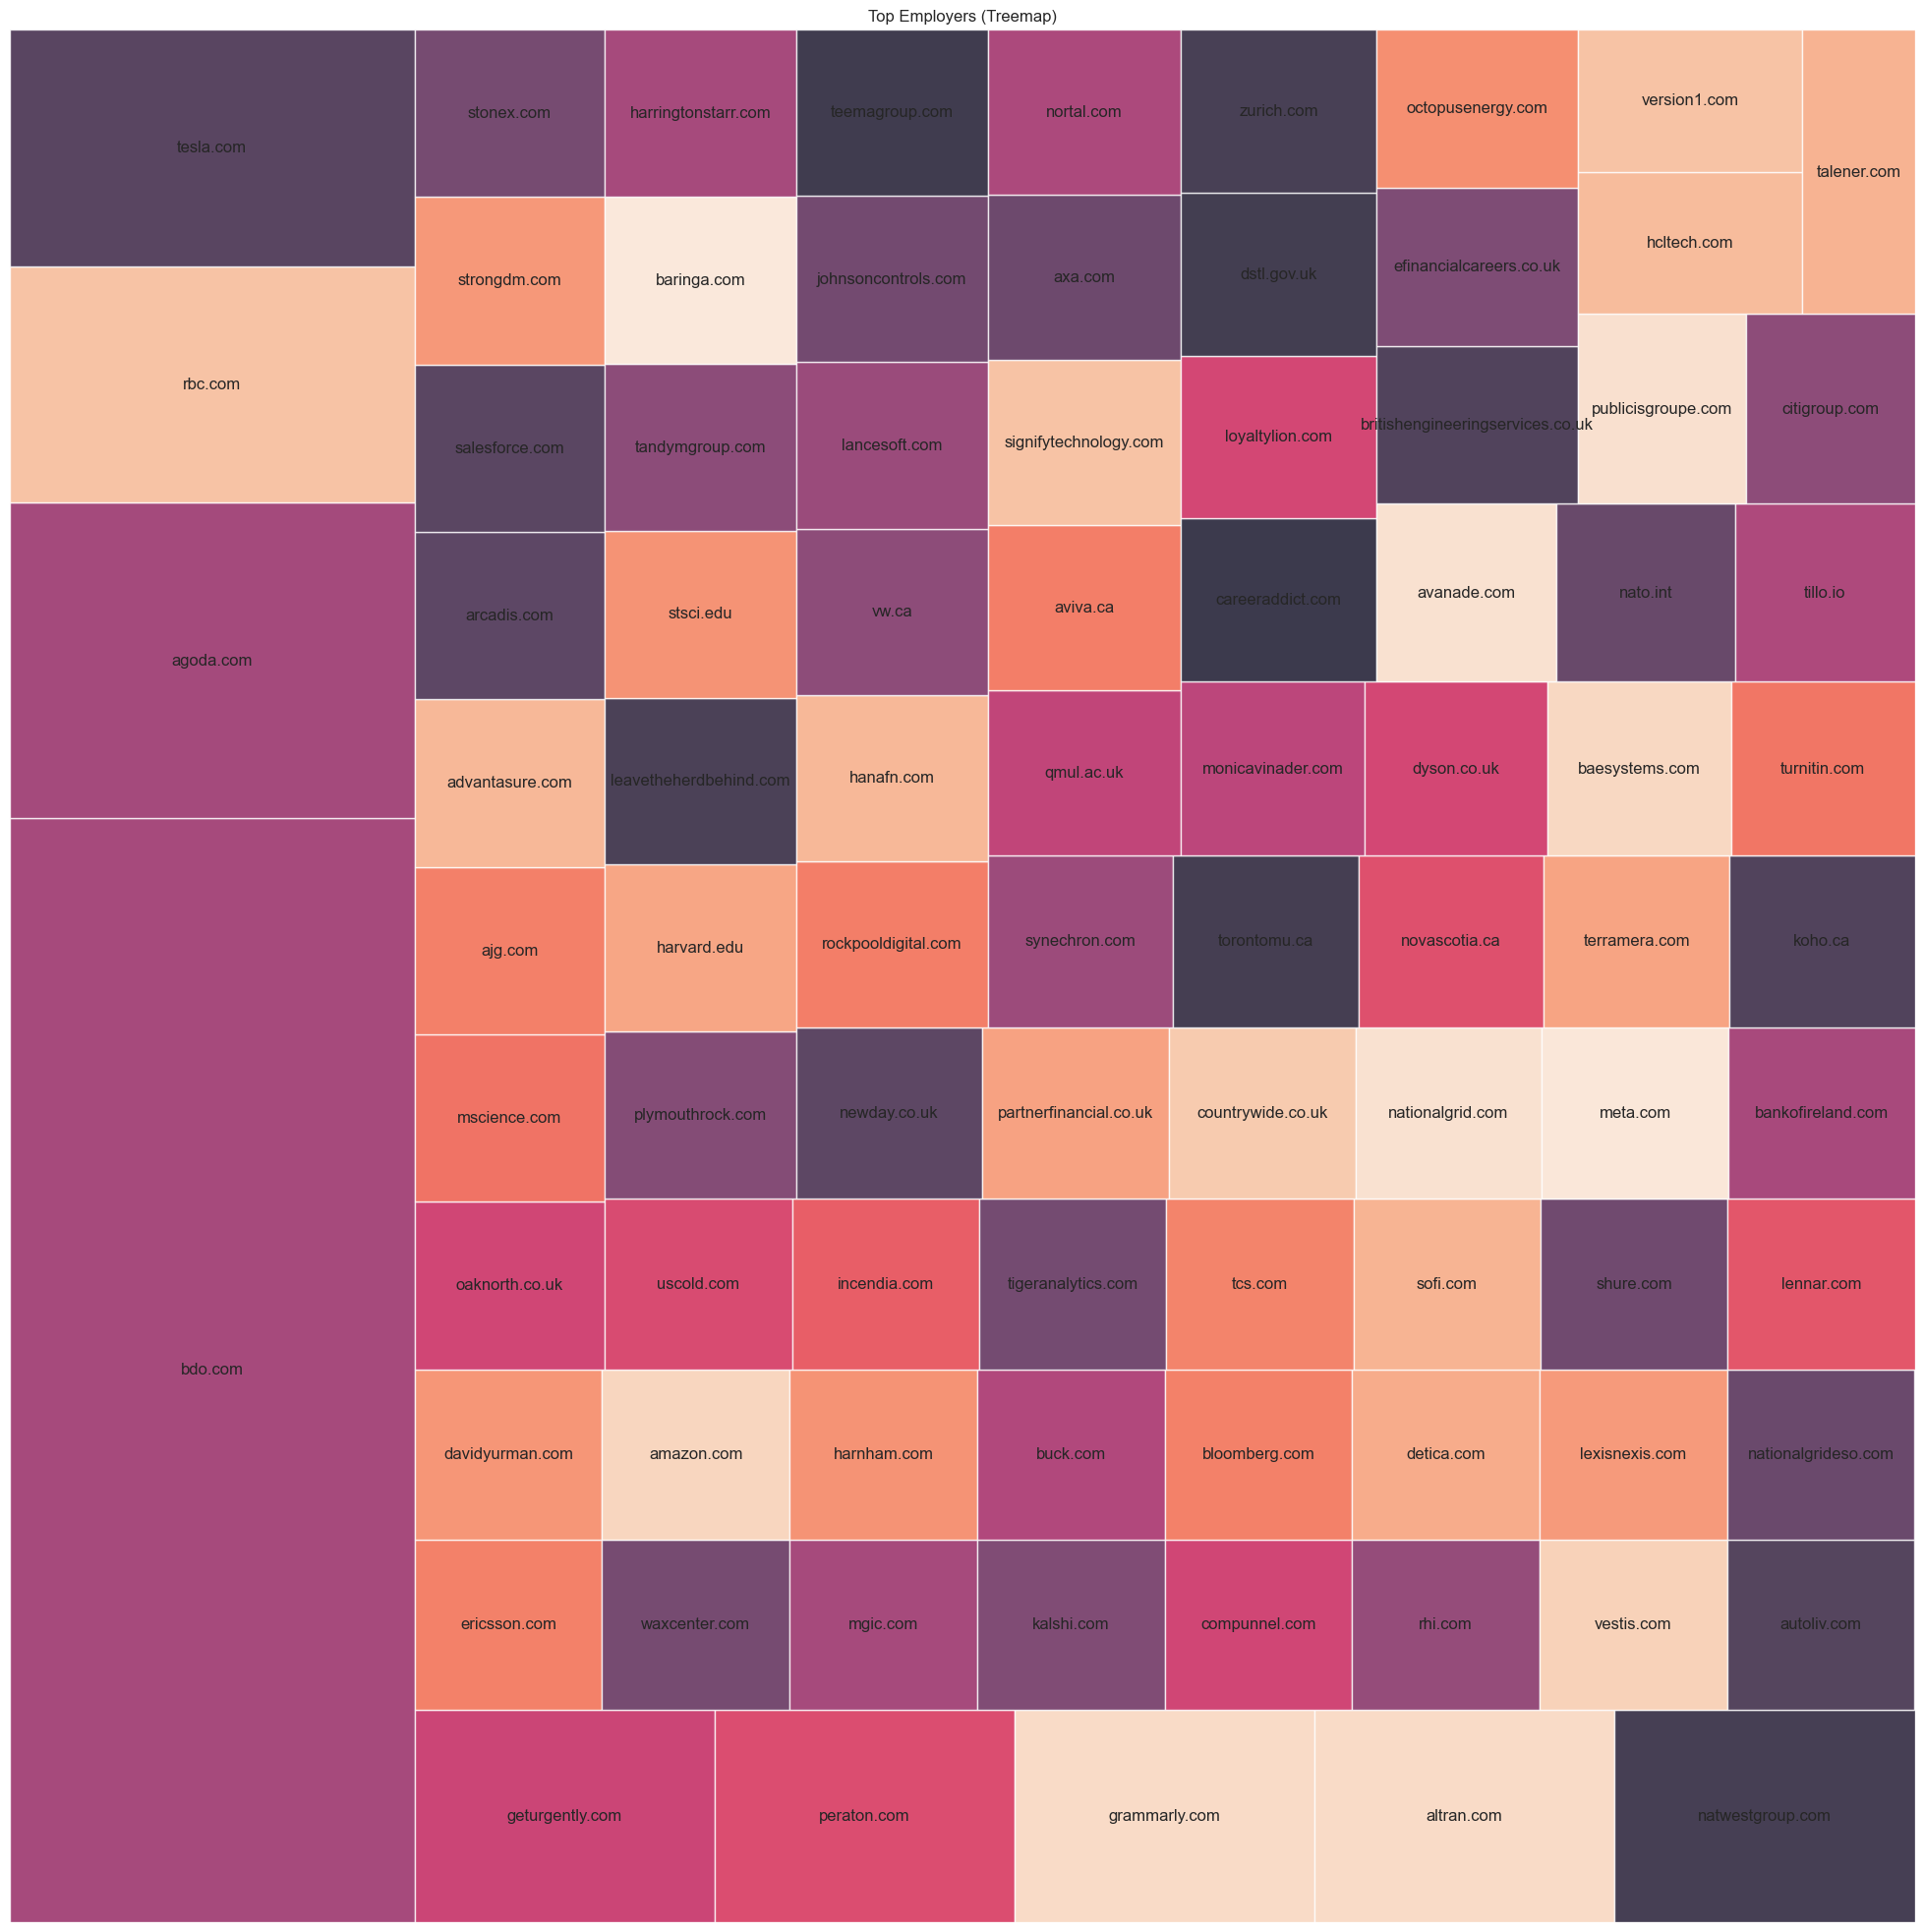

In [261]:
import squarify

# Plot a treemap
plt.figure(figsize=(25, 25))
squarify.plot(sizes=cleaned_counts.values, label=cleaned_counts.index, alpha=0.8)
plt.axis('off')  # Remove axis
plt.title('Top Employers (Treemap)')
plt.show()


In [ ]:
!pip install networkx

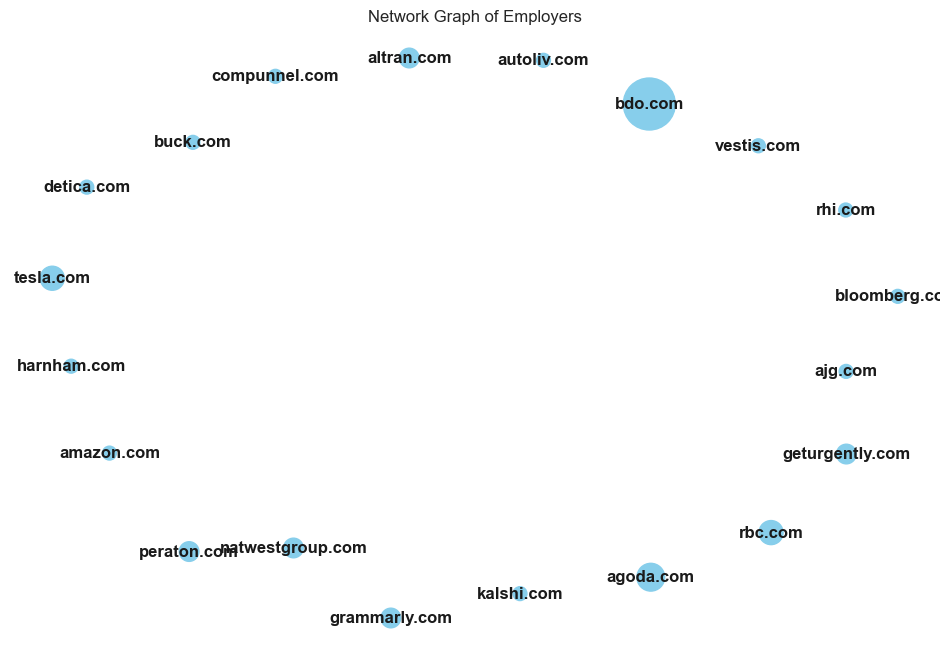

In [262]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Your data
data = {
    "Employer": [
        "bdo.com", "agoda.com", "rbc.com", "tesla.com", "natwestgroup.com",
        "peraton.com", "grammarly.com", "geturgently.com", "altran.com", "buck.com",
        "harnham.com", "amazon.com", "ajg.com", "bloomberg.com", "autoliv.com",
        "detica.com", "vestis.com", "rhi.com", "compunnel.com", "kalshi.com"
    ],
    "Count": [
        14, 4, 3, 3, 2, 2, 2, 2, 2, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1
    ]
}

# Create a DataFrame
df2 = pd.DataFrame(data)

# Create a directed graph
G = nx.DiGraph()

# Add nodes to the graph
for employer, count in zip(df2["Employer"], df2["Count"]):
    G.add_node(employer, count=count)

# Draw the network graph
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G)  # Position nodes using the spring layout algorithm

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=[d['count'] * 100 for n, d in G.nodes(data=True)])

# Draw edges
nx.draw_networkx_edges(G, pos)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

plt.title("Network Graph of Employers")
plt.axis('off')  # Remove axis
plt.show()

## JOB DESCRIPTION

In [263]:
from wordcloud import WordCloud

In [264]:
df.columns

Index(['job_id', 'job_employment_type', 'job_title', 'job_apply_link',
       'job_description', 'job_city', 'job_country', 'job_posted_at_timestamp',
       'employer_website', 'employer_company_type'],
      dtype='object')

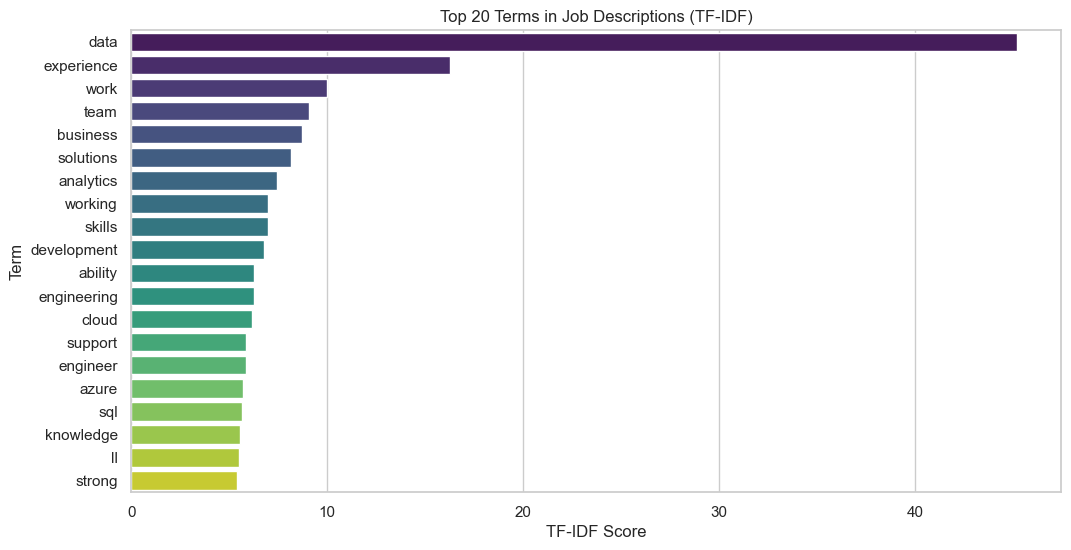

In [265]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

# Assuming 'job_description' is the column containing job descriptions
job_descriptions = df['job_description'].dropna()

# TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = vectorizer.fit_transform(job_descriptions)

# Summing TF-IDF scores across all documents for each term
term_scores = tfidf_matrix.sum(axis=0)

# Getting the feature names (terms)
feature_names = vectorizer.get_feature_names_out()

# Creating a DataFrame to store term scores
term_scores_df = pd.DataFrame(data={'Term': feature_names, 'Score': term_scores.flat})

# Sorting terms by score in descending order
term_scores_df = term_scores_df.sort_values(by='Score', ascending=False)

# Visualizing the top terms
plt.figure(figsize=(12, 6))
sns.barplot(x='Score', y='Term', data=term_scores_df.head(20), palette='viridis')
plt.title('Top 20 Terms in Job Descriptions (TF-IDF)')
plt.xlabel('TF-IDF Score')
plt.ylabel('Term')
plt.show()


## JOB TITLES...

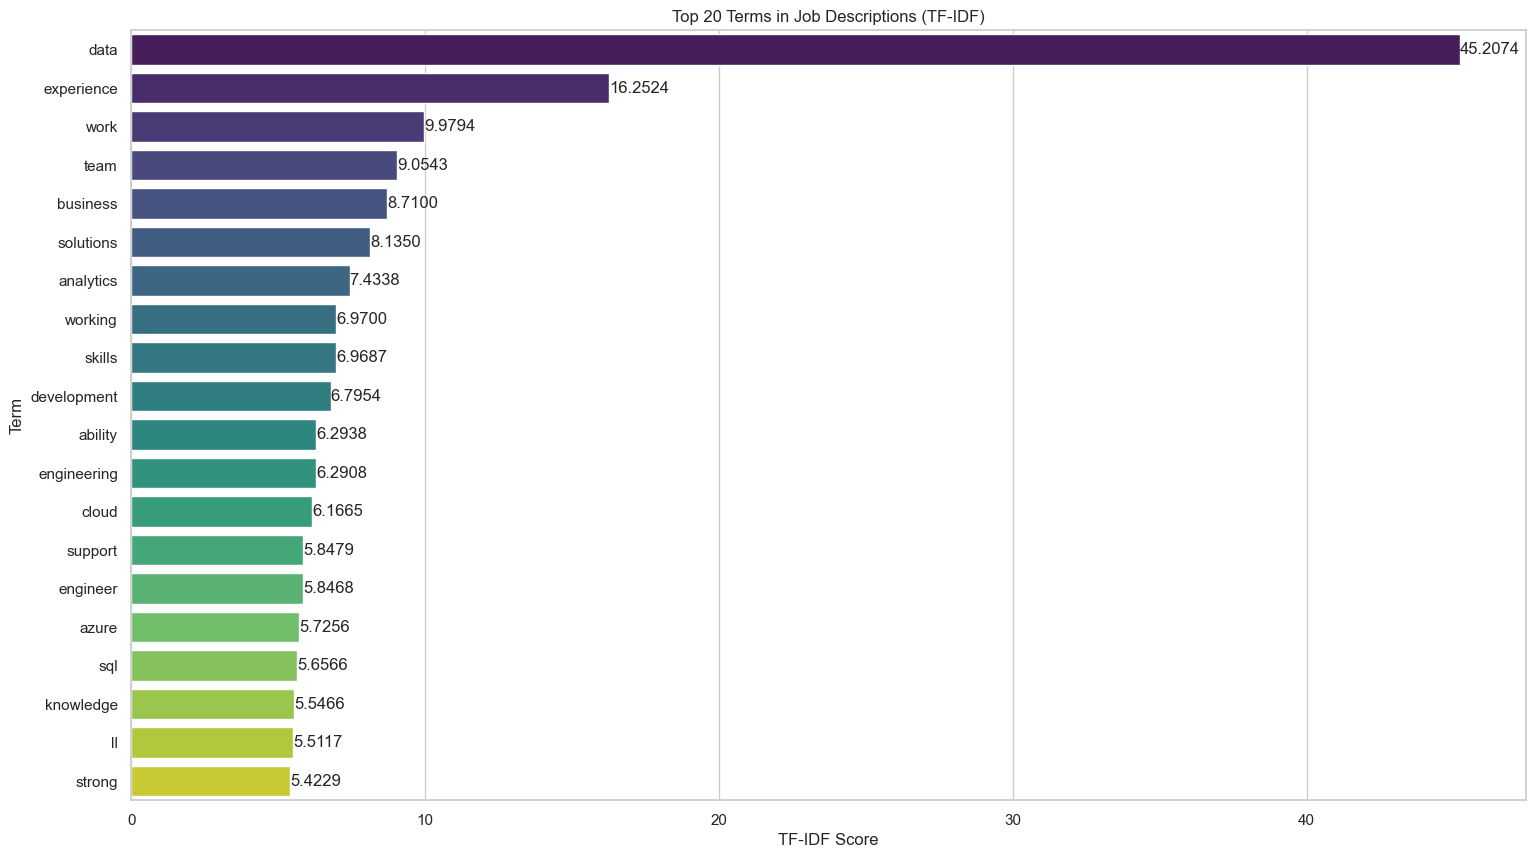

In [266]:
# Assuming 'job_description' is the column containing job descriptions
job_descriptions = df['job_description'].dropna()

# TF-IDF vectorizer
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
tfidf_matrix = vectorizer.fit_transform(job_descriptions)

# Summing TF-IDF scores across all documents for each term
term_scores = tfidf_matrix.sum(axis=0)

# Getting the feature names (terms)
feature_names = vectorizer.get_feature_names_out()

# Creating a DataFrame to store term scores
term_scores_df = pd.DataFrame(data={'Term': feature_names, 'Score': term_scores.flat})

# Sorting terms by score in descending order
term_scores_df = term_scores_df.sort_values(by='Score', ascending=False)

# Visualizing the top terms
plt.figure(figsize=(18, 10))
barplot = sns.barplot(x='Score', y='Term', data=term_scores_df.head(20), palette='viridis')
plt.title('Top 20 Terms in Job Descriptions (TF-IDF)')
plt.xlabel('TF-IDF Score')
plt.ylabel('Term')

# Adding data labels to the bars
for index, value in enumerate(term_scores_df.head(20)['Score']):
    barplot.text(value, index, f'{value:.4f}', ha='left', va='center')

plt.show()

## Observations: 

- Data appeared in the job description most
- followed by Experience, Work, team, business, solutions, anlaytics etc.


## JOB DESCRIPTION USING WORD COUNT

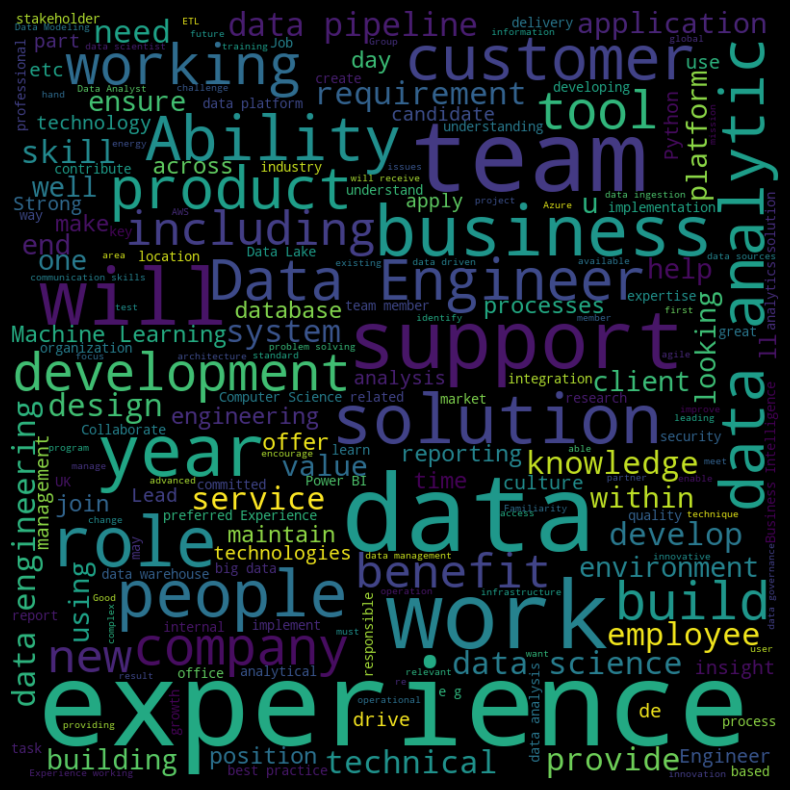

In [267]:
from wordcloud import WordCloud
job_description = df['job_description']

# Combine all job descriptions into a single string
words_str = ' '.join(job_description)

# Generate word cloud
wordcloud = WordCloud(width=800, height=800,
                      background_color='black',
                      stopwords=None,  # You may or may not want to use stopwords
                      min_font_size=10
                     ).generate(words_str)

# Plot the WordCloud image with matplotlib
plt.figure(figsize=(10, 10), facecolor='black')
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


- The term "data" emerges as the most frequently utilized keyword in 
job descriptions, closely followed by "experience" and "work". 

- These keywords are commonly encountered in various job postings, underscoring their significance
in articulating job requirements and qualifications within the employment landscape.


In [268]:
data_scientists = []
data_analysts = []
data_engineers = []
dual_roles = []

for title in df['job_title']:
    if 'data scientist' in title.lower():
        data_scientists.append(title)
    elif 'data analyst' in title.lower():
        data_analysts.append(title)
    elif 'engineer' in title.lower():
        data_engineers.append(title)
    else:
        dual_roles.append(title)

# Optionally, you can convert the lists to sets to remove duplicates
data_scientists = list(set(data_scientists))
data_analysts = list(set(data_analysts))
data_engineers = list(set(data_engineers))
dual_roles = list(set(dual_roles))

print("Data Scientists:", data_scientists)
print("----------------------------------------------------------------------------------------------------------------")
print(" ")
print("Data Analysts:", data_analysts)
print("----------------------------------------------------------------------------------------------------------------")
print(" ")
print("Data Engineers:", data_engineers)
print("----------------------------------------------------------------------------------------------------------------")
print(" ")
print("Dual Roles:", dual_roles)

Data Scientists: ['Data Scientist, Model Risk (12 Month Contract)', 'Data Analyst/Data Scientist – Hedge Fund – London', 'Lead Data Scientist (Bangkok based, relocation provided)', 'Senior Data Scientist, Acquisition', 'Senior Data Scientist / Machine Learning Engineer', 'Data Scientist', 'Data Scientist / Data Analyst', 'Data Scientist/ Engineer', 'Data Scientist Industrial Placement - ESO']
----------------------------------------------------------------------------------------------------------------
 
Data Analysts: ['Data Analyst/ Engineer', 'Quality Data Analyst', 'Lead Data Analyst', 'Data Analyst (Bangkok Based, relocation provided)', 'Senior Data Analyst (Product Team) (Bangkok Based, relocation provided)', 'Business Data Analyst', 'Entry Level Data Analyst/Management Consultant - Nationwide (US Based Candidates Only)', 'Associate Data Analyst', 'Undergraduate Data Analyst Industrial Placement', '2024 Investor Services - Business Data Analyst Co-op (12 months)', 'Product Suppo

In [269]:

# Get counts of each category
data_scientist_count = len(data_scientists)
data_analyst_count = len(data_analysts)
data_engineer_count = len(data_engineers)
dual_roles_count = len(dual_roles)

print("Data Scientists Count:", data_scientist_count)
print("Data Analysts Count:", data_analyst_count)
print("Data Engineers Count:", data_engineer_count)
print("Dual roles:", dual_roles_count)

Data Scientists Count: 9
Data Analysts Count: 20
Data Engineers Count: 60
Dual roles: 10


         job role  job role count
0  Data Scientist               9
1    Data Analyst              20
2   Data Engineer              60
3      Dual Roles              10


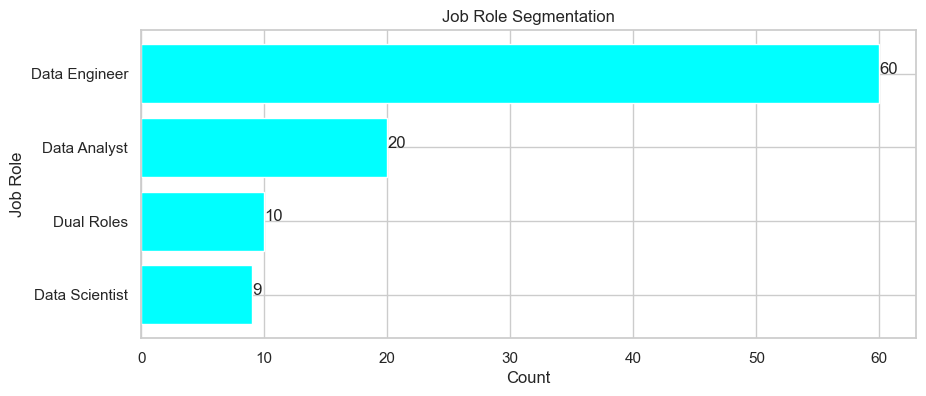

In [277]:
job_roles = ["Data Scientist", "Data Analyst", "Data Engineer", "Dual Roles"]
job_counts = [data_scientist_count, data_analyst_count, data_engineer_count, dual_roles_count]

job_segmentation = pd.DataFrame({
    'job role': job_roles,
    'job role count': job_counts
})

# Display the DataFrame
print(job_segmentation)

# Sort the DataFrame by counts in descending order
job_segmentation = job_segmentation.sort_values(by='job role count', ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(10, 4))
plt.barh(job_segmentation['job role'], job_segmentation['job role count'], color='cyan')
plt.xlabel('Count')
plt.ylabel('Job Role')
plt.title('Job Role Segmentation')
# Display counts beside each bar
for index, value in enumerate(job_segmentation['job role count']):
    plt.text(value, index, str(value))
plt.show()

## Observations:
 - Data Engineers based on Job Role Segmentation are 60 positions
 - Data Analysts positions are 20
 - Dual Roles are 10 positions
 - Data Scientists have 9 roles.

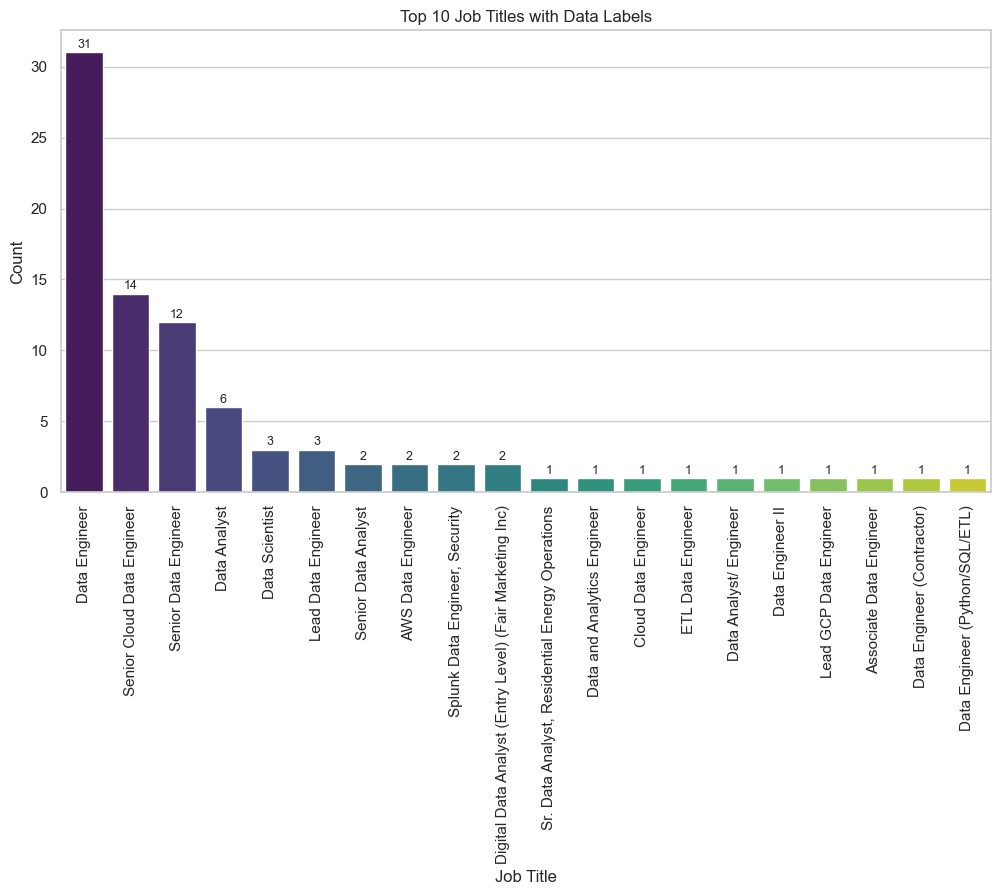

In [272]:
# Set the style for better visualization
sns.set(style="whitegrid")

# Top Ten Job Titles
top_job_titles = df['job_title'].value_counts().nlargest(20)

plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=top_job_titles.index, y=top_job_titles.values, palette='viridis')

# Add data labels on top of each bar
for index, value in enumerate(top_job_titles):
    barplot.text(index, value + 0.1, str(value), ha='center', va='bottom', fontsize=9)

plt.title('Top 10 Job Titles with Data Labels')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()



## JOB LINK ANALYSIS

In [37]:
#Extracting the Job Link for further exploration
from urllib.parse import urlparse

urls = df['job_apply_link']

# Extract the site names from the URLs
site_names1 = [urlparse(url).netloc for url in urls]


# Convert the list to a pandas Series and get the unique counts
unique_site_counts = pd.Series(site_names1).value_counts()

# Display the unique counts of each URL
print(unique_site_counts)

www.linkedin.com             69
uk.linkedin.com              37
ca.linkedin.com              25
gb.bebee.com                  9
onlydatajobs.com              6
ca.bebee.com                  3
www.ziprecruiter.com          2
jobs.rbc.com                  2
findajob.dwp.gov.uk           2
careers.axa.com               1
jobs.ajg.com                  1
ai-jobs.net                   1
www.cv-library.ie             1
www.investigo.co.uk           1
www.recruit.net               1
careers.bankofireland.com     1
www.hfg.co.uk                 1
www.climatetechlist.com       1
hitmarker.net                 1
www.clearancejobs.com         1
dtype: int64


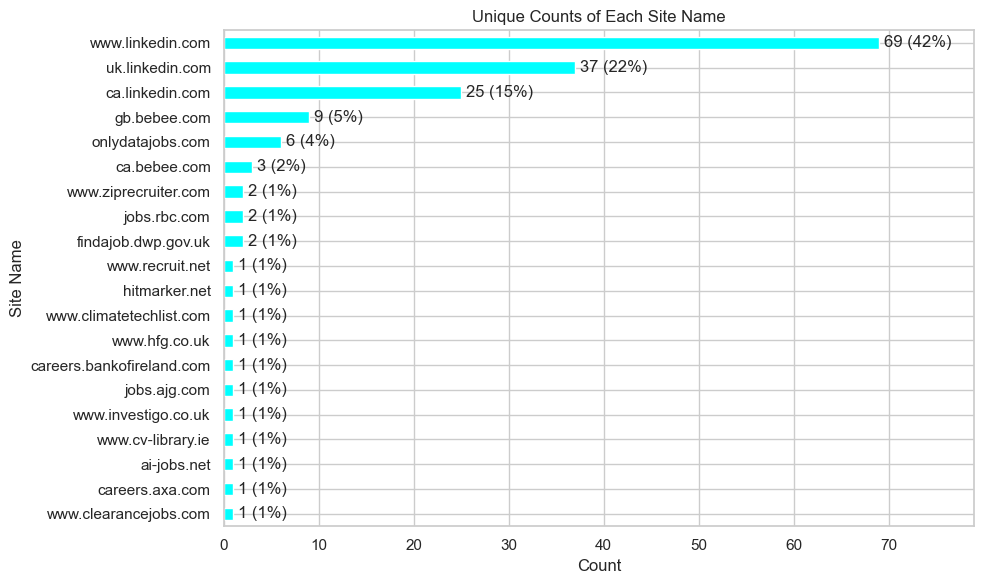

In [276]:
# Using horizontal bar chart to visualize the count and percentage of the job link
urls = df['job_apply_link']

# Extract the site names from the URLs
site_names1 = [urlparse(url).netloc for url in urls]

# Convert the list to a pandas Series and get the unique counts
unique_site_counts = pd.Series(site_names1).value_counts()

# Sort the unique counts in descending order
unique_site_counts_sorted = unique_site_counts.sort_values(ascending=False)

# Calculate the percentage of each site's contribution to the total
percentages = (unique_site_counts_sorted / unique_site_counts_sorted.sum()) * 100

# Plot horizontal bar chart with annotations for percentages
plt.figure(figsize=(10, 6))
ax = unique_site_counts_sorted.plot(kind='barh', color='cyan')
plt.xlabel('Count')
plt.ylabel('Site Name')
plt.title('Unique Counts of Each Site Name')
plt.gca().invert_yaxis()  # Invert y-axis to have the highest count at the top

# Annotate each bar with its percentage contribution
for i, v in enumerate(unique_site_counts_sorted):
    ax.text(v + 0.5, i, f'{v} ({percentages.iloc[i]:.0f}%)', va='center')

plt.xlim(right=max(unique_site_counts_sorted) + 10)  # Set xlim with some padding

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

## Observations

- Linkedin US is toping the chart with 42%
- Linkedin UK is 22%
- Linkedin CA is 15%
- gb.bebee is 5%
- onlydatajobs is 4%
- ca.bebee is 2% 
- While the others are 1% each.

## BIVARIATE ANALYSIS

In [50]:
df.columns

Index(['job_employment_type', 'job_title', 'job_apply_link', 'job_description',
       'job_country', 'job_posted_at_timestamp'],
      dtype='object')

## TOP 10 EMPLOYMENT TYPE BY JOB TITLE

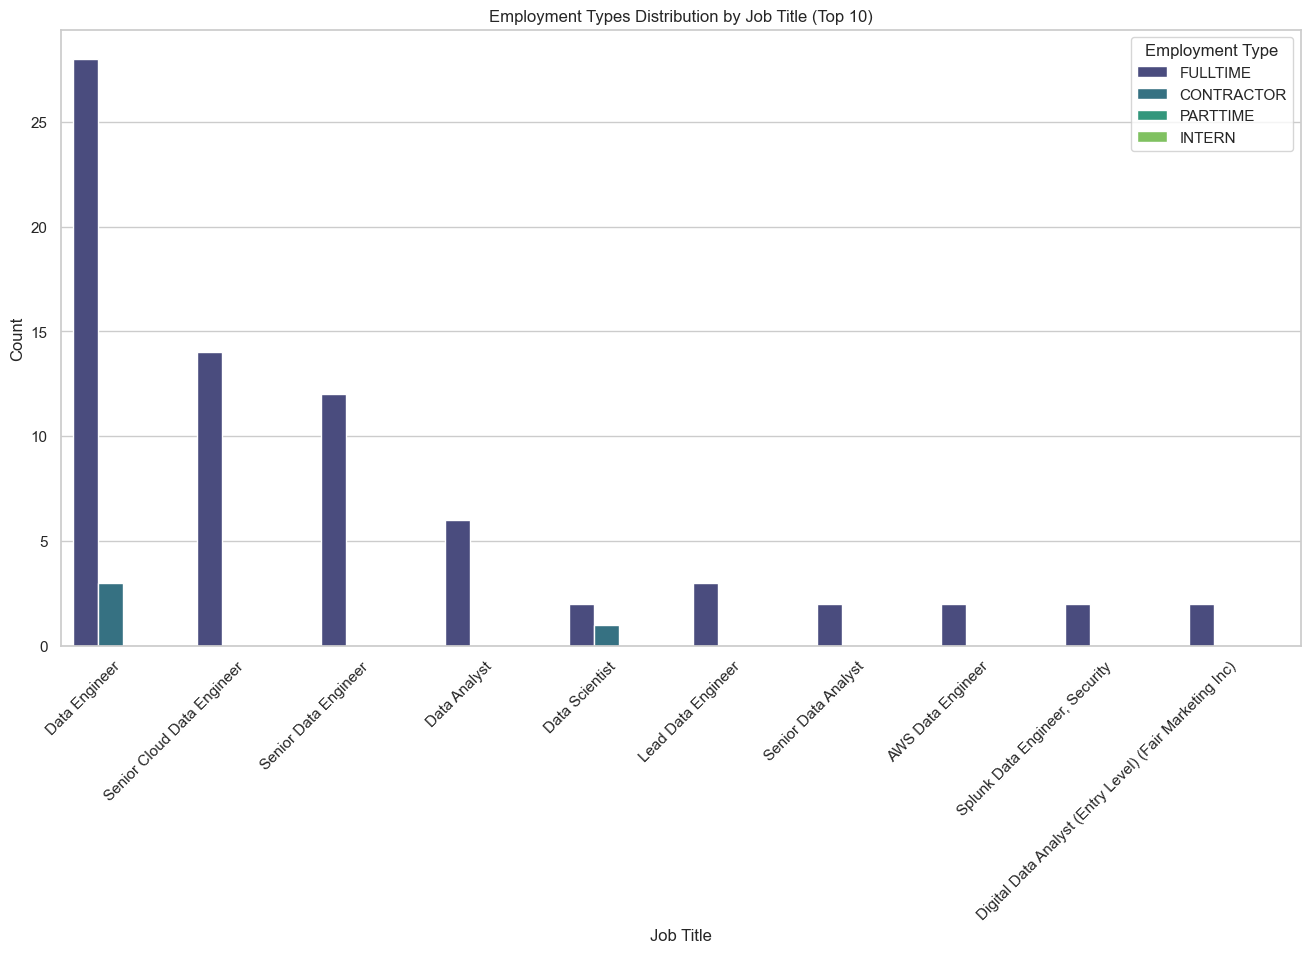

In [289]:
plt.figure(figsize=(16, 8))
sns.countplot(x="job_title", hue="job_employment_type", data=df, palette='viridis', order=df['job_title'].value_counts().index[:10])
plt.title('Employment Types Distribution by Job Title (Top 10)')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Employment Type')
plt.show()

- Data Engineer is the most common job title on the list, with over 28 job postings for full time and 3 for part time.


- There is a mix of entry-level and senior-level positions on the list, suggesting that there are opportunities 
for people with all levels of experience.


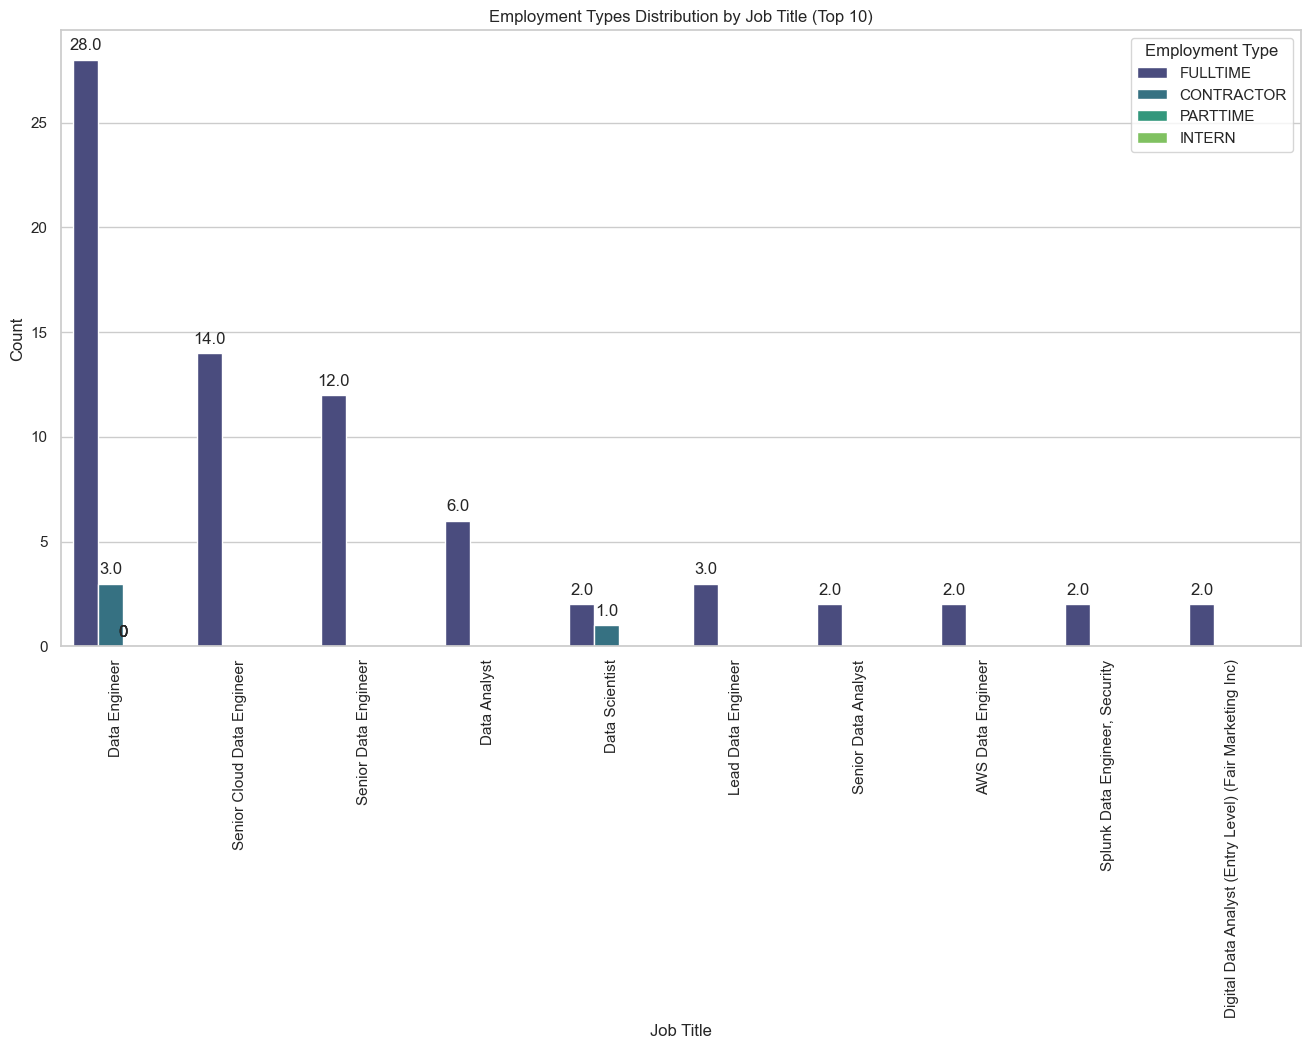

In [292]:
# Employment Types Distribution by Job Title (Top 10)
plt.figure(figsize=(16, 8))
ax = sns.countplot(x="job_title", hue="job_employment_type", data=df, palette='viridis', order=df['job_title'].value_counts().index[:10])
plt.title('Employment Types Distribution by Job Title (Top 10)')
plt.xlabel('Job Title')
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Employment Type')

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()




## EMPLOYMENT TYPE DISTRIBUTION BY JOB COUNTRY

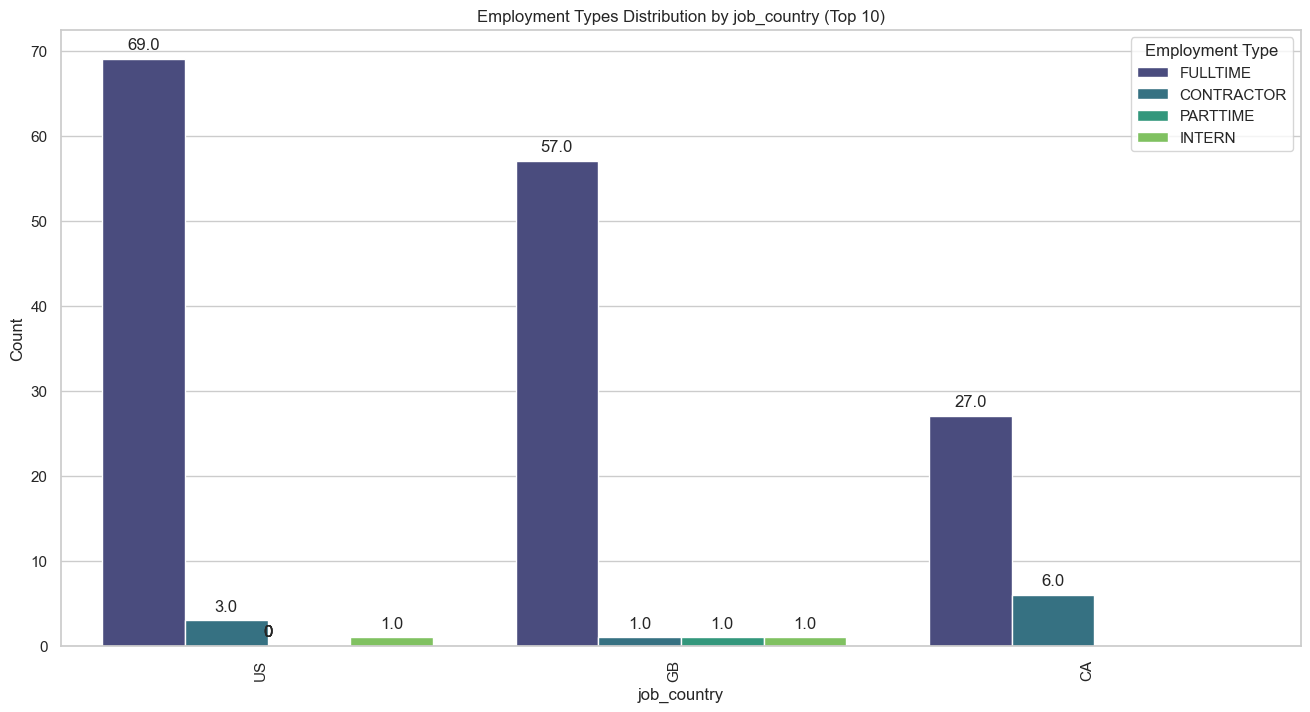

In [293]:
# Employment Types Distribution by Job Country (Top 10)
plt.figure(figsize=(16, 8))
ax = sns.countplot(x="job_country", hue="job_employment_type", data=df, palette='viridis', order=df["job_country"].value_counts().index[:10])
plt.title('Employment Types Distribution by job_country (Top 10)')
plt.xlabel('job_country')
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Employment Type')

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

## Observations: 

- United States had 69 Full Time Jobs, 3 Contractors and 1 Intern job applicants
- Great Britain had 57 Full time Jobs, 1 Contractor, 1 Part time and 1 Intern job applicants
- Canada declared 27 Full time vacancies and 6 Contrators.


- Full-time positions dominate all three countries, comprising the majority of job postings. 



- This suggests a preference for stable, long-term employment arrangements in these regions.



## EMPLOYMENT TYPES DISTRIBUTION BY JOB CITY

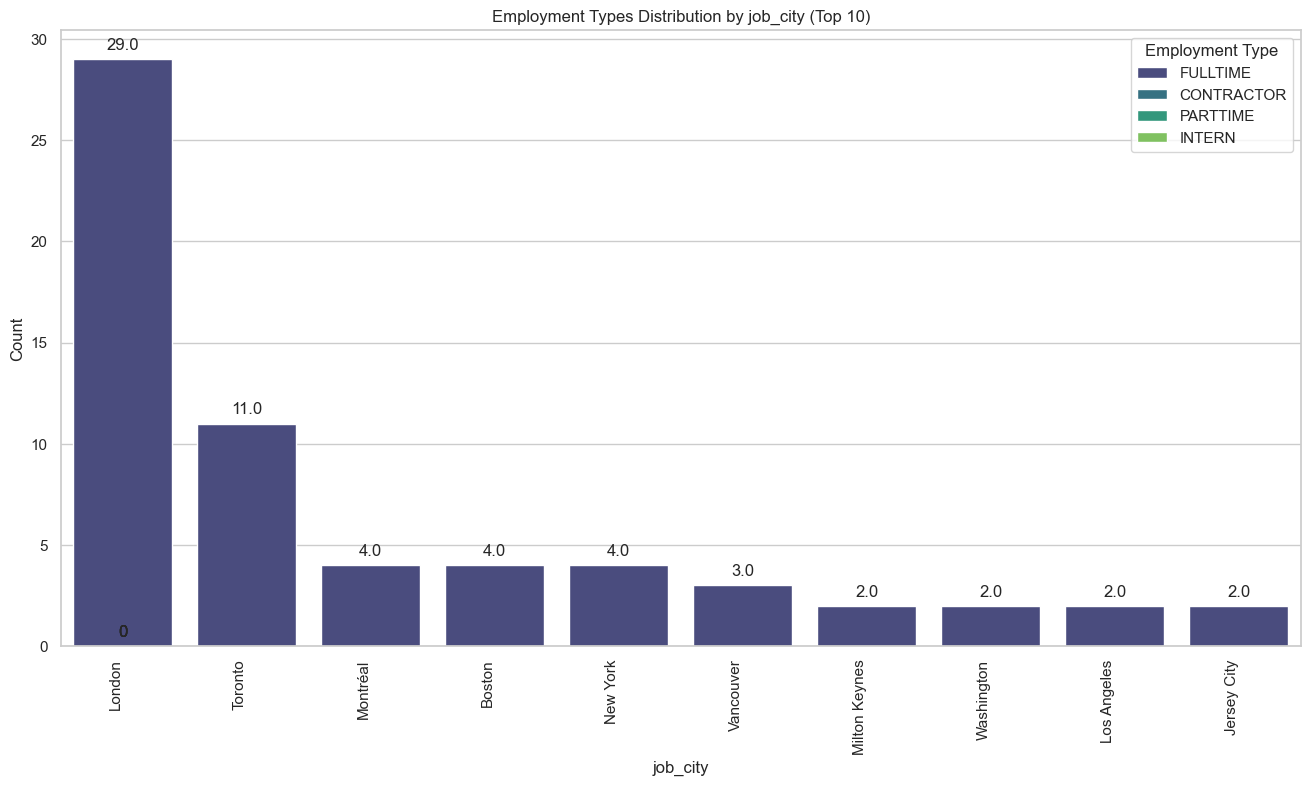

In [294]:
# Employment Types Distribution by Job City (Top 10)
plt.figure(figsize=(16, 8))
ax = sns.countplot(x="job_city", hue="job_employment_type", data=df, palette='viridis', order=df["job_city"].value_counts().index[:10])
plt.title('Employment Types Distribution by job_city (Top 10)')
plt.xlabel("job_city")
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Employment Type')

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

The chart revealed the following details:
    
    - London had 29 Full time jobs applicants
    - Toronto had 11 Full Time Job applicants
    - Montreal, Boston and New York had 4 job applicants
    - Vancouver had 3 job applicants
    - Milton Keynes, Washington, Los Angeles and Jersey City had 2 job applicants
    

## Employment Types Distribution by employer_company_type (Top 10)

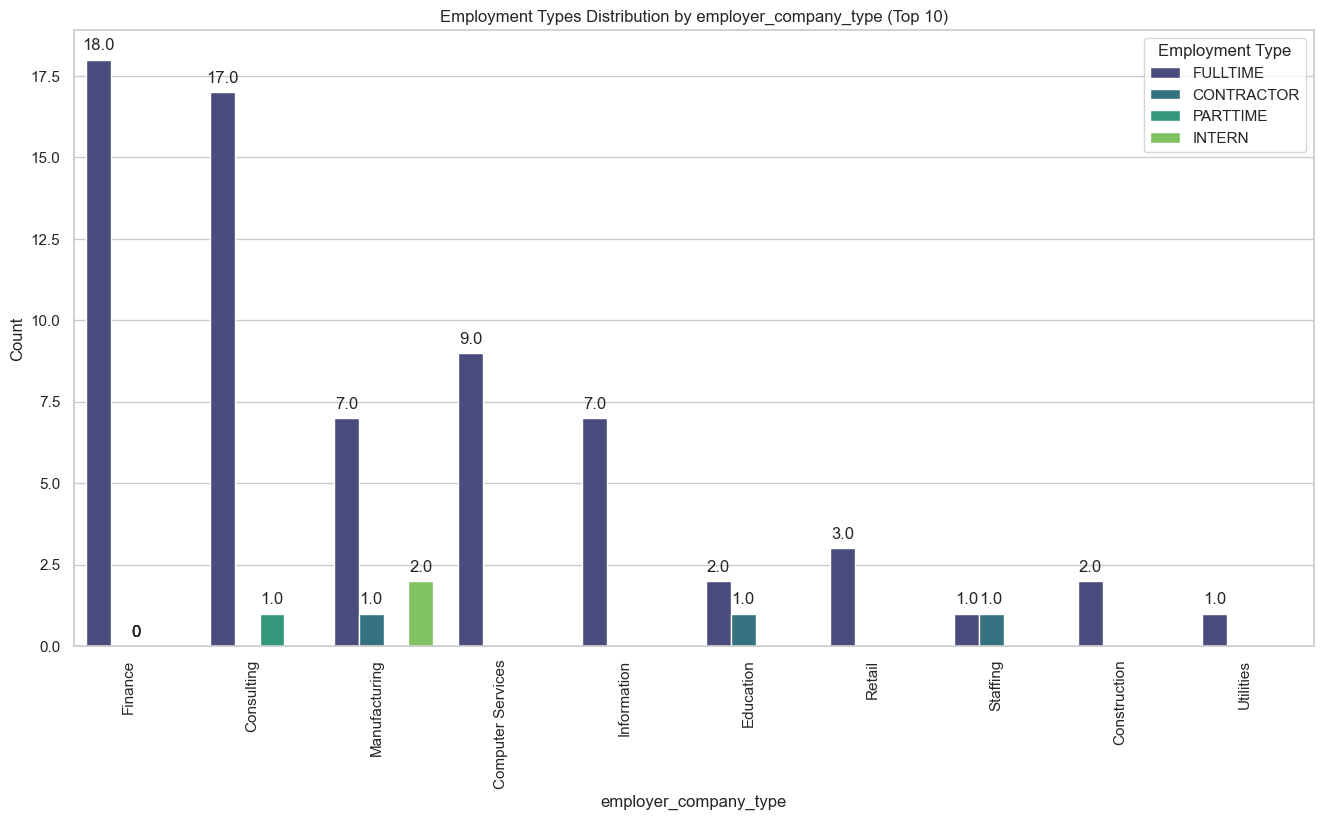

In [296]:
# Employment Types Distribution by employer_company_type (Top 10)
plt.figure(figsize=(16, 8))
ax = sns.countplot(x="employer_company_type", hue="job_employment_type", data=df, palette='viridis', order=df["employer_company_type"].value_counts().index[:10])
plt.title('Employment Types Distribution by employer_company_type (Top 10)')
plt.xlabel("employer_company_type")
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Employment Type')

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

## Observations: 

    -  Finance sector had 18 Full Time jobs
    -  Consulting sector had 17 Full Time jobs and 1 Part Time Job.
    -  Manufacturing sector had 7 Full Time jobs, 1 Contrator Job and 2 Interns... 
    -  Computer Service sector had 9 Full Time jobs
    -  Information sector had 7 Full Time jobs
    -  Education sector had 2 Full Time jobs and 1 Contractor Job
    -  Retail sector had 3 Full Time jobs
    -  Staffing sector had 1 Full Time job and 1 Contractor Job
    -  Construction sector had 2 Full Time jobs
    -  Utilities sector has 1 Full Time job.
    
    
    - Full-time positions dominate the Finance, Computer Services, and Utilities sectors, suggesting a strong preference for long-term, dedicated personnel. Consulting stands out with a significant portion of fulltime roles, alongside parttime roles.
    
    - Manufacturing, Education and Staffing sectors each have one job posting of contractor roles.


## INSIGHTS

INSIGHTS: 
    
    
 - I.    In contrast to Great Britain and Canada, the dataset suggests a higher volume of job openings in the United States.


- II.   A predominant portion, specifically 41.57%, of job postings originates from linkedin.com, with LinkedIn.com 
        leading in the number of job postings, followed by uk.linkedin.com.


- III.  London and Toronto stand out as the cities boasting the highest number of job openings, indicating a robust employment market in these metropolitan centers.

- IV.   The field of finance and consulting emerges as the sector with the most significant number of job openings tailored for technology experts. 
        This observation underscores the demand within these industries for skilled professionals adept in technology-related roles, 
        reflecting the ongoing convergence of technology and financial services as well as consulting practices.
        
- V.    Among the common terms found in job descriptions, 'data' emerges as the most frequently utilized, followed closely by 'experience' and 'work'. 

        These keywords are prevalent throughout various job postings, reflecting their significance in conveying job requirements and qualifications. Top of Form

- VI.   The most common employment type for these job titles is full-time, with around 92% of job postings being for full-time positions. Contractor roles are the second most common, at around 6%, followed by part-time roles at around 1%. 
        Internship roles make up around 1% of the postings.

        There is a high demand for data science and engineering skills, as many of the job titles on the list are related to these fields.


        
        An examination of employer type distribution within job postings across the United States, Great Britain, and Canada reveals intriguing patterns:

    Full-time employment reigns supreme: Full-time positions dominate all three countries, comprising the majority of job postings. This suggests a preference for stable, long-term employment arrangements in these regions.

    
    Part-time prominence in Canada: Interestingly, Canada stands out with a higher prevalence of part-time job postings compared to the US and UK. This could be attributed to factors like a flexible work culture catering to student populations or a desire for work-life balance.

    Contract and internship discrepancies: A curious observation lies in the absence of contract and internship postings from Canada in the data. This warrants further investigation into potential reasons behind this discrepancy, such as differing data sources or specific job board limitations.

    Cultivating young talent: US and UK lead in internships: 
            
    The US and UK exhibit a higher concentration of internship opportunities compared to Canada. This might indicate a stronger emphasis on nurturing young talent and providing early career exposure in these countries.

    
    Across the cities analyzed in this data set, a striking trend emerges:
 full-time job postings reign supreme. 

This observation suggests a strong overall preference for stable, long-term employment arrangements within the represented locations. Notably, London takes the top spot, boasting the highest concentration of full-time job postings amongst the ten leading cities.

Following closely behind is Toronto, further solidifying the presence of full-time opportunities in this major metropolitan center.


Certain employer websites stand out with higher counts of job postings.

For example, "http://www.bdo.com" leads with 14 job postings, followed by "http://www.agoda.com" with 4 postings. This indicates the presence of prominent employers actively recruiting through their websites.

The distribution of job postings across employer websites may reflect sector-specific trends. For instance, websites like "http://www.bdo.com" and "http://www.rbc.com"

are associated with financial and professional services, while "http://www.tesla.com" represents the technology and automotive sector. This suggests sector-specific recruitment strategies employed by different employers.



## RECOMENDATIONS


    JOB SEEKERS:For Job Seekers:

- Target the U.S. Job Market: 
    
    Given the higher volume of job openings in the United States compared to Great Britain and Canada, consider exploring opportunities in the U.S. market. Leverage online job portals and professional networking platforms to identify relevant roles.

- Utilize LinkedIn Effectively: 
    
    With LinkedIn.com being the primary source of job postings, ensure your LinkedIn profile is updated, optimized, and showcases your skills and experiences effectively. Actively engage with industry content, join relevant groups, and network with professionals to increase visibility and access opportunities.

- Explore specific locations: 
    
    Consider London and Toronto for a wider range of full-time opportunities: London and Toronto emerge as cities with robust employment markets for tech professionals. Consider targeting job opportunities in these metropolitan centers, where demand for technology expertise is high.

- Explore Finance and Consulting Roles: 
    
    The finance and consulting industries offer significant job openings tailored for technology experts. Upskill in relevant areas such as fintech and data analytics to capitalize on opportunities within these sectors.

- Target prominent employer websites: 
    
    Research companies like BDO and Agoda that actively recruit through their websites.

- Highlight data skills: 
    
    Emphasize your data literacy, analytical abilities, and relevant data tools experience in your resume and cover letter. Data is the most sought-after skill across various industries.

- Use relevant keywords: 
   
    Include data-related keywords in job search.

        
        

    RECRUITERS & EMPLOYER: 
        
        
        For Employers and Recruiters:

    - Tap into the U.S. 
    
    - Talent Pool: 
        
        With a higher volume of job openings in the United States, consider expanding recruitment efforts to tap into the diverse talent pool available in the U.S. market.

    - Leverage LinkedIn for Recruitment: 
        
        Given that a predominant portion of job postings originates from LinkedIn, utilize the platform effectively for recruitment purposes. Post job vacancies, engage with potential candidates, and leverage LinkedIn's advanced search features to identify suitable talent.
    - Target London and Toronto for Talent Acquisition: 
        
    London and Toronto stand out as cities with high job openings, indicating a robust talent pool in these metropolitan centers. Focus recruitment efforts in these regions to access skilled tech professionals.
    - Explore Collaboration with Finance and Consulting Sectors: 
        
    Given the demand for technology expertise in the finance and consulting industries, consider collaborating with organizations in these sectors to identify talent and explore potential partnerships for talent development and recruitment initiatives.
    - Emphasize data skills: 
        
    Clearly outline data-related requirements and responsibilities in job descriptions to attract qualified candidates.
    - Utilize employer websites:
        
    Leverage your website as a recruitment platform and maintain updated job postings.
    - Offer diverse employment options: 
        
    Consider offering part-time and contract roles alongside full-time positions to cater to different preferences.

